# 🛰️ Kalman Filter (Bộ lọc Kalman) & Hợp nhất xác suất (Probabilistic Fusion): Bài Lab Thực Hành
### Từ "những con số nhiễu" đến một bộ theo dõi (tracker) hợp nhất (fuse) LiDAR, radar và camera, trong 2 giờ, chỉ dùng NumPy thuần

| ⏱ phút | Phần | Bạn làm gì trong buổi lab |
|:--:|:--|:--|
| 5 | **0. Thiết lập** | Chạy một lần |
| 25 | **1–3. Trung bình trượt → Kalman 1 chiều** | Code đã điền sẵn. Chạy, đọc biểu đồ và hộp Nhận định. Không chấm |
| 10 | **4. NIS** | Code đã điền sẵn. Thấy NIS ≈ 1. Bảng dấu vân tay này dùng lại ở Phần 9. Không chấm |
| 25 | **5. Kalman dạng ma trận** | Tự code bài 5.1 và 5.2. Có chấm |
| 12 | **6. Hợp nhất LiDAR + radar + camera** | Tự code bài 6.1. Có chấm |
| 10 | **7. Outlier** | Tự code bài 7.1. Mục độ trễ chỉ chạy. Có chấm |
| 25 | **9. Nhiệm vụ Lynx-07** | Đọc NIS, khai báo chẩn đoán, chọn một cách sửa, viết một báo cáo. Có chấm |
| 8 | **Đệm** | Hỏi nếu kẹt. Phần 8 và các mục sau giờ không tính vào 120 phút |

**Tổng: 120 phút, làm và nộp trong buổi lab.** 80 điểm chấm tự động, 20 điểm một báo cáo (xem mục 📋 ở cuối). Phần 8 (EKF) và mục sau giờ là thưởng, tối đa +5, không cần để xong buổi.

### Cách bài lab này hoạt động
- Chạy các cell **từ trên xuống dưới**. Chạy cell **✅ kiểm tra (check cell)** sau mỗi bài tập; nó sẽ cho bạn biết ngay liệu bạn làm đúng hay chưa.
- Phần 1–4 đã điền sẵn code. Hãy chạy và đọc, không cần sửa, không chấm điểm.
- ✏️ Bài **5.1, 5.2, 6.1, 7.1** còn `raise NotImplementedError`. Thay bằng code của bạn. Gợi ý nằm trong comment.
- Phần 9: hàm lọc đã có sẵn. Bạn điền bốn biến (`MY_DIAGNOSIS_*`, `FIX_SENSOR`, `FIX_METHOD`) và một báo cáo.
- 💡 Hộp **Insight (Nhận định)** là ý cần nhớ. ⚠️ Hộp **Pitfall (Cạm bẫy)** là lỗi kỹ sư hay mắc.
- Kẹt hơn 5 phút ở bài 5–7? Xem notebook lời giải. Phần 9 thì tự đọc số NIS của bạn — đáp án phụ thuộc `STUDENT_ID`.

### Mã màu (giống nhau trong mọi biểu đồ)
<span style="color:#2563EB">■ **xanh dương (blue)** = dự đoán (prediction)</span> &nbsp; <span style="color:#EA7B12">■ **cam (orange)** = phép đo (measurement)</span> &nbsp; <span style="color:#059669">■ **xanh lá (green)** = ước lượng của bộ lọc (filter estimate)</span> &nbsp; <span style="color:#13233B">■ **tối (dark)** = giá trị thật (ground truth)</span>

**Yêu cầu:** Python 3.9+, `numpy`, `matplotlib`, `scipy`. Chạy được trên laptop hoặc Google Colab (upload file `.ipynb`). Các cell slider tương tác còn dùng `ipywidgets` và là tùy chọn.


## Phần 0 · Thiết lập (Setup) (5 phút)
Chạy cell này một lần. Nó import các thư viện và định nghĩa vài hàm hỗ trợ vẽ đồ thị (plotting helpers). Bạn chưa cần đọc code hỗ trợ này ngay bây giờ.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2

# colour code used everywhere
BLUE, ORANGE, GREEN, RED, GREY, INK = "#2563EB", "#EA7B12", "#059669", "#DC2626", "#94A3B8", "#13233B"

plt.rcParams.update({
    "figure.figsize": (10, 4), "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": .25, "axes.titleweight": "bold", "axes.titlesize": 12,
    "legend.frameon": False, "axes.axisbelow": True,
})
trapz = getattr(np, "trapezoid", None) or np.trapz      # works on old and new NumPy

def rmse(a, b=0.0):
    """Compute the root-mean-square error between two arrays.

    Args:
        a: Array-like of values (e.g. an estimate or sensor reading).
        b: Array-like (or scalar) of reference values to compare against.
            Defaults to 0.0, which turns this into the RMS of `a` itself.

    Returns:
        float: The root-mean-square of (a - b).
    """
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def cov_ellipse(ax, mean, cov, n_std=2.0, **kw):
    """Draw an n-sigma confidence ellipse for a 2x2 covariance matrix.

    Args:
        ax: Matplotlib Axes to draw on.
        mean: Length-2 array-like, the ellipse center (e.g. estimated position).
        cov: 2x2 covariance matrix whose eigenvectors/eigenvalues set the
            ellipse orientation and size.
        n_std: Number of standard deviations the ellipse should span.
            Defaults to 2.0 (~95% confidence region for a 2-D Gaussian).
        **kw: Extra keyword arguments forwarded to
            `matplotlib.patches.Ellipse` (e.g. edgecolor, facecolor, alpha).

    Returns:
        None: The ellipse patch is added directly to `ax`.
    """
    vals, vecs = np.linalg.eigh(cov)                       # ascending eigenvalues
    angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
    w, h = 2 * n_std * np.sqrt(vals[::-1])
    ax.add_patch(Ellipse(mean, w, h, angle=angle, **kw))

print("Setup OK  -  numpy", np.__version__)

Setup OK  -  numpy 2.1.2


---
## Phần 1 · Tại sao chúng ta cần một bộ lọc (filter)? (trong 25 phút Phần 1–3 · chạy để xem, không chấm)
🎯 **Mục tiêu:** cảm nhận được vấn đề mà Kalman filter (bộ lọc Kalman) giải quyết.

Một robot di chuyển dọc theo một đường thẳng. Có hai nguồn thông tin cho biết nó đang ở đâu:

* **Odometry (đo hành trình)** (bộ mã hóa bánh xe - wheel encoders): chúng ta biết đã *ra lệnh* cho nó di chuyển bao xa ở mỗi bước, nhưng bánh xe bị trượt một chút, nên vị trí thật trôi dần khỏi kế hoạch.
* **Một cảm biến kiểu GPS** báo trực tiếp vị trí, nhưng có rất nhiều nhiễu (noise) (σ = 2 m).

Chúng ta mô phỏng thế giới để có thể tự chấm điểm cho mình. **Trong đời thực, bạn không bao giờ thấy được đường "giá trị thật (ground truth)" màu xanh lá, và đó chính xác là lý do bài toán này khó.**


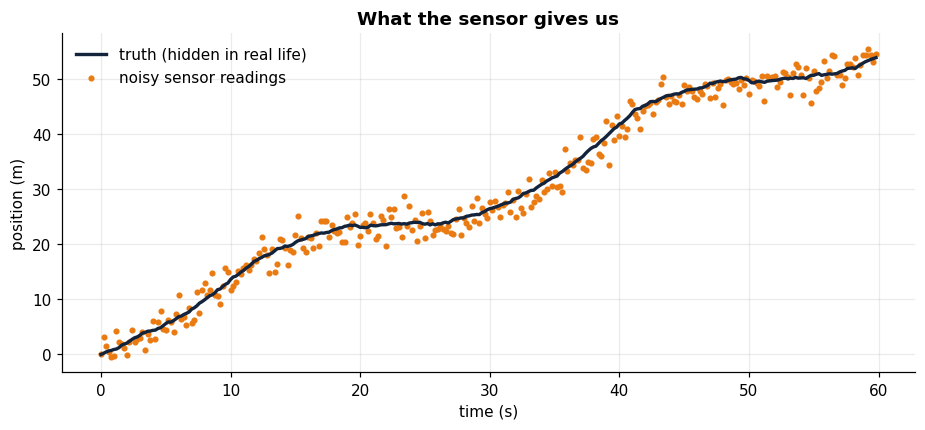

Raw sensor error: RMSE = 1.86 m


In [2]:
def simulate_1d(n=300, dt=0.2, q_sd=0.15, r_sd=2.0, seed=7):
    """Simulate a robot driving on a line with noisy odometry and sensor.

    Args:
        n: Number of simulation steps.
        dt: Time step, in seconds.
        q_sd: Standard deviation of the process noise (how much the wheels
            actually slip each step), in meters.
        r_sd: Standard deviation of the position sensor noise, in meters.
        seed: Seed for the random number generator, for reproducibility.

    Returns:
        tuple: `(t, x, z, u)` -- the time vector, the TRUE (hidden)
        position, the noisy sensor reading, and the commanded odometry
        step at each time.
    """
    rng = np.random.default_rng(seed)
    t = np.arange(n) * dt
    v = 1.0 + 0.8 * np.sin(2 * np.pi * t / 30)      # speed we command (m/s)
    u = v * dt                                       # odometry: distance we THINK we moved this step
    x = np.zeros(n)
    for k in range(1, n):
        x[k] = x[k - 1] + u[k] + rng.normal(0, q_sd)  # reality: wheels slip a little
    z = x + rng.normal(0, r_sd, n)                    # GPS-like sensor: noisy
    return t, x, z, u

DT, Q_SD_TRUE, R_SD_TRUE = 0.2, 0.15, 2.0
t, x_true, z, u = simulate_1d(dt=DT, q_sd=Q_SD_TRUE, r_sd=R_SD_TRUE)

fig, ax = plt.subplots()
ax.plot(t, x_true, color=INK, lw=2.2, label="truth (hidden in real life)")
ax.scatter(t, z, s=9, color=ORANGE, label="noisy sensor readings")
ax.set(xlabel="time (s)", ylabel="position (m)", title="What the sensor gives us")
ax.legend(); plt.show()
print(f"Raw sensor error: RMSE = {rmse(z, x_true):.2f} m")

### 🔮 Dự đoán trước
Cách khắc phục nhiễu (noise) hiển nhiên nhất là **lấy trung bình (averaging)**. Nếu ta lấy trung bình *k* phép đo gần nhất:
**(a)** *k* càng lớn thì càng tốt, luôn luôn đúng **(b)** tốt hơn lúc đầu, rồi lại tệ đi **(c)** lấy trung bình không bao giờ giúp ích

Viết dự đoán của bạn ra, rồi tiếp tục.

### ▶️ Bài tập 1.1 · Trung bình trượt nhân quả (đã điền sẵn, không chấm)
Hàm `moving_average(z, k)` dưới đây đã có sẵn: với mỗi chỉ số `i`, trả về giá trị trung bình của `k` phép đo gần nhất **tính đến và bao gồm** `i`. Ở lúc bắt đầu, khi có ít hơn `k` phép đo, hãy lấy trung bình của những gì đang có. *Nhân quả (causal)* nghĩa là không được "nhìn trộm" tương lai: một robot không thể dùng những phép đo mà nó chưa nhận được.


In [3]:
def moving_average(z, k):
    """Compute the causal moving average of a signal.

    Args:
        z: 1-D array of noisy readings.
        k: Window size; each output averages at most the last `k` readings
            up to and including the current index.

    Returns:
        numpy.ndarray: Same length as `z`; `out[i]` is the mean of
        `z[i-k+1 : i+1]` (fewer values are averaged near the start).
    """
    out = np.zeros(len(z))
    for i in range(len(z)):
        out[i] = np.mean(z[max(0, i - k + 1): i + 1])
    return out


In [4]:
def check_moving_average():
    """Verify `moving_average` against a hand-computed example.

    Raises:
        AssertionError: If `moving_average` does not match the expected
            output for a small, hand-checkable input.
    """
    out = moving_average(np.array([1., 2., 3., 4., 5.]), 3)
    assert np.allclose(out, [1, 1.5, 2, 3, 4]), f"expected [1, 1.5, 2, 3, 4], got {out}"
    print("✅ Exercise 1.1 passed")
check_moving_average()

✅ Exercise 1.1 passed


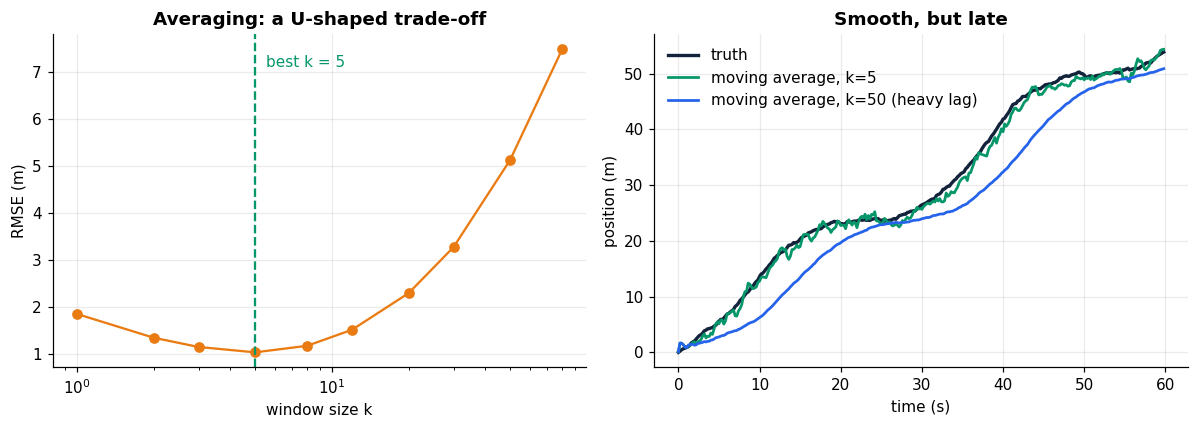

Best moving average: RMSE = 1.04 m   (raw sensor: 1.86 m)


In [5]:
ks = np.array([1, 2, 3, 5, 8, 12, 20, 30, 50, 80])
errs = [rmse(moving_average(z, k), x_true) for k in ks]
k_best = int(ks[np.argmin(errs)])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(ks, errs, "o-", color=ORANGE); a1.set_xscale("log")
a1.axvline(k_best, color=GREEN, ls="--"); a1.text(k_best * 1.1, max(errs) * .95, f"best k = {k_best}", color=GREEN)
a1.set(xlabel="window size k", ylabel="RMSE (m)", title="Averaging: a U-shaped trade-off")

a2.plot(t, x_true, color=INK, lw=2.2, label="truth")
a2.plot(t, moving_average(z, k_best), color=GREEN, lw=1.8, label=f"moving average, k={k_best}")
a2.plot(t, moving_average(z, 50), color=BLUE, lw=1.8, label="moving average, k=50 (heavy lag)")
a2.set(xlabel="time (s)", ylabel="position (m)", title="Smooth, but late"); a2.legend()
plt.tight_layout(); plt.show()
print(f"Best moving average: RMSE = {min(errs):.2f} m   (raw sensor: {rmse(z, x_true):.2f} m)")

> ### 💡 Nhận định (Insight)
> Bất kỳ bộ làm mượt (smoother) nào chỉ nhìn vào các *phép đo (measurement)* quá khứ đều đánh đổi **nhiễu (noise) lấy độ trễ (lag)**. Một Kalman filter phá vỡ sự đánh đổi này bằng cách còn sử dụng thêm một **mô hình chuyển động (model) của robot** (ở đây: odometry). Nó biết tương đối robot *nên* ở đâu tiếp theo, và chỉ dùng cảm biến để sửa lại dự đoán đó.

---
## Phần 2 · Niềm tin (belief) là các phân phối Gaussian, và hợp nhất hai niềm tin (cùng khối 25 phút · chạy để xem, không chấm)
🎯 **Mục tiêu:** hiểu công thức duy nhất chi phối toàn bộ việc hợp nhất cảm biến (sensor fusion).

Một Kalman filter biểu diễn câu hỏi "robot đang ở đâu?" dưới dạng một **đường cong hình chuông (bell curve), hay phân phối Gaussian (Gaussian)**:
* **trung bình (mean) μ** là dự đoán tốt nhất,
* **phương sai (variance) σ²** cho biết chúng ta không chắc chắn đến mức nào. Đường cong hẹp nghĩa là tự tin, đường cong rộng nghĩa là không chắc chắn.

Giả sử hai nguồn độc lập đều đưa ra một niềm tin (belief) về cùng một đại lượng. **Nhân hai đường cong lại** (cả hai phải đúng cùng lúc) và bạn sẽ có một phân phối Gaussian mới:

$$\mu = \frac{\mu_1\sigma_2^2 + \mu_2\sigma_1^2}{\sigma_1^2+\sigma_2^2}\qquad\qquad \sigma^2 = \frac{\sigma_1^2\,\sigma_2^2}{\sigma_1^2+\sigma_2^2}$$

Diễn đạt tương đương theo ngôn ngữ "độ chính xác (precision)" (precision = 1/σ²): $\;\frac{1}{\sigma^2}=\frac{1}{\sigma_1^2}+\frac{1}{\sigma_2^2}$. **Các độ chính xác (precision) cộng dồn với nhau. Nguồn nào "sắc nét" (chính xác) hơn sẽ được tin tưởng (trọng số) nhiều hơn.**

**Ví dụ minh họa.** Nguồn A nói 10 m (σ² = 4), nguồn B nói 12 m (σ² = 1):
μ = (10·1 + 12·4) / (4 + 1) = **11.6** và σ² = 4·1 / (4 + 1) = **0.8**. Kết quả nghiêng về phía B (nguồn chính xác hơn) và *chắc chắn hơn cả hai nguồn ban đầu*.


### ▶️ Bài tập 2.1 · Đường cong Gaussian hình chuông (đã điền sẵn, không chấm)
$$\mathcal N(x;\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\Big(-\frac{(x-\mu)^2}{2\sigma^2}\Big)$$
Hàm `gaussian_pdf(x, mu, var)` đã điền sẵn. Lưu ý tham số đầu vào là **phương sai (variance)** σ², không phải độ lệch chuẩn (standard deviation).


In [6]:
def gaussian_pdf(x, mu, var):
    """Evaluate the Gaussian (normal) probability density function.

    Args:
        x: Point(s) at which to evaluate the density (scalar or array).
        mu: Mean of the distribution.
        var: Variance of the distribution (must be positive).

    Returns:
        The density value(s) p(x) for a Normal(mu, var) distribution, same
        shape as `x`.
    """
    return np.exp(-(x - mu) ** 2 / (2 * var)) / np.sqrt(2 * np.pi * var)


In [7]:
def check_gaussian_pdf():
    """Verify `gaussian_pdf` has the right peak value and unit area.

    Raises:
        AssertionError: If the peak density or the total area under the
            curve is wrong.
    """
    assert np.isclose(gaussian_pdf(0.0, 0.0, 1.0), 1 / np.sqrt(2 * np.pi)), "peak of N(0,1) should be 0.3989"
    xs = np.linspace(-20, 20, 4001)
    assert np.isclose(trapz(gaussian_pdf(xs, 3.0, 4.0), xs), 1.0, atol=1e-4), "area under the curve must be 1"
    print("✅ Exercise 2.1 passed")
check_gaussian_pdf()

✅ Exercise 2.1 passed


### ▶️ Bài tập 2.2 · Hợp nhất hai niềm tin (belief) (đã điền sẵn, không chấm)
Hàm `fuse(mu1, var1, mu2, var2)` đã điền sẵn và trả về `(mu, var)` của niềm tin đã được hợp nhất (fused belief). Sử dụng các công thức ở trên. **Kiểm tra lại với ví dụ minh họa:** bạn phải thu được kết quả 11.6 và 0.8.


In [8]:
def fuse(mu1, var1, mu2, var2):
    """Fuse two independent Gaussian beliefs by precision-weighting.

    Args:
        mu1: Mean of the first belief (e.g. a prediction).
        var1: Variance of the first belief.
        mu2: Mean of the second belief (e.g. a measurement).
        var2: Variance of the second belief.

    Returns:
        tuple: `(mu, var)` of the fused Gaussian -- a precision-weighted
        average of the two inputs, with variance smaller than either input.
    """
    mu = (mu1 * var2 + mu2 * var1) / (var1 + var2)
    var = var1 * var2 / (var1 + var2)
    return mu, var


In [9]:
def check_fuse():
    """Verify `fuse` against two hand-checkable cases.

    Raises:
        AssertionError: If the fused mean/variance don't match the
            expected values for an asymmetric-trust and an equal-trust case.
    """
    mu, var = fuse(10, 4, 12, 1)
    assert np.isclose(mu, 11.6) and np.isclose(var, 0.8), f"expected (11.6, 0.8), got ({mu}, {var})"
    mu, var = fuse(5, 2, 9, 2)
    assert np.isclose(mu, 7.0) and np.isclose(var, 1.0), "equal trust -> midpoint, half the variance"
    print("✅ Exercise 2.2 passed")
check_fuse()

✅ Exercise 2.2 passed


### 🔮 Dự đoán trước
Chúng ta hợp nhất A (μ=10) với B (μ=12) trong ba tình huống. Đường cong xanh lá (đã hợp nhất) sẽ nằm ở đâu, và sẽ rộng bao nhiêu?
**①** A mơ hồ (σ²=4), B sắc nét (σ²=1) **②** cả hai cùng sắc nét như nhau (σ²=1) **③** B gần như vô dụng (σ²=100)

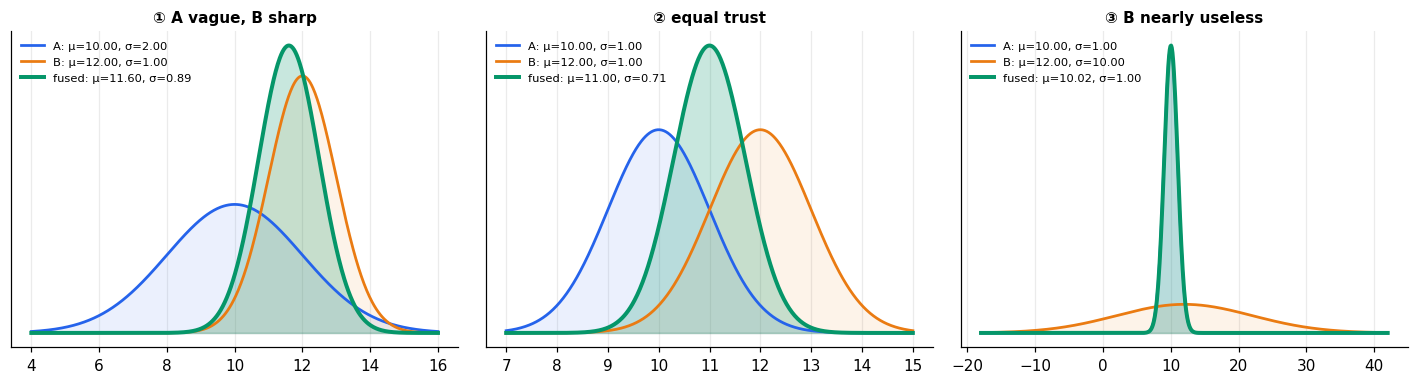

In [10]:
def plot_fusion(ax, m1, v1, m2, v2, title=""):
    """Plot two Gaussian beliefs and their fused result on one axis.

    Args:
        ax: Matplotlib Axes to draw on.
        m1: Mean of belief A.
        v1: Variance of belief A.
        m2: Mean of belief B.
        v2: Variance of belief B.
        title: Optional title for the subplot.

    Returns:
        None: The curves are drawn directly on `ax`.
    """
    m, v = fuse(m1, v1, m2, v2)
    lo = min(m1 - 3 * np.sqrt(v1), m2 - 3 * np.sqrt(v2)); hi = max(m1 + 3 * np.sqrt(v1), m2 + 3 * np.sqrt(v2))
    xs = np.linspace(lo, hi, 600)
    for mu, var, c, lab in [(m1, v1, BLUE, "A"), (m2, v2, ORANGE, "B"), (m, v, GREEN, "fused")]:
        y = gaussian_pdf(xs, mu, var)
        ax.plot(xs, y, color=c, lw=2.6 if c == GREEN else 1.8, label=f"{lab}: μ={mu:.2f}, σ={np.sqrt(var):.2f}")
        ax.fill_between(xs, y, color=c, alpha=.22 if c == GREEN else .09)
    ax.set_title(title, fontsize=10); ax.set_yticks([]); ax.legend(fontsize=7.5, loc="upper left")

fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
plot_fusion(axs[0], 10, 4, 12, 1, "① A vague, B sharp")
plot_fusion(axs[1], 10, 1, 12, 1, "② equal trust")
plot_fusion(axs[2], 10, 1, 12, 100, "③ B nearly useless")
plt.tight_layout(); plt.show()

**Kiểm tra tính hợp lý từ nguyên lý cơ bản (sanity check).** Liệu hàm `fuse` có thực sự tương đương với "nhân hai đường cong rồi chuẩn hóa lại (renormalise)" không? Hãy kiểm tra bằng số trên một lưới (grid) mịn.

In [11]:
xs = np.linspace(0, 20, 4001)
prod = gaussian_pdf(xs, 10, 4) * gaussian_pdf(xs, 12, 1)
prod /= trapz(prod, xs)                                         # renormalise so the area is 1
mean_num = trapz(xs * prod, xs); var_num = trapz((xs - mean_num) ** 2 * prod, xs)
mu_f, var_f = fuse(10, 4, 12, 1)
print(f"numerical product : mean = {mean_num:.4f}, variance = {var_num:.4f}")
print(f"your fuse()       : mean = {mu_f:.4f}, variance = {var_f:.4f}")
assert np.isclose(mean_num, mu_f, atol=1e-3) and np.isclose(var_num, var_f, atol=1e-3)
print("✅ identical: the formula IS 'multiply the curves'")

numerical product : mean = 11.6000, variance = 0.8000
your fuse()       : mean = 11.6000, variance = 0.8000
✅ identical: the formula IS 'multiply the curves'


### 🎛️ Tùy chọn · thử nghiệm (cần Jupyter hoặc Colab)
Kéo các thanh trượt (slider) và quan sát đường cong xanh lá. Thử làm cho một cảm biến nhiễu hơn hẳn cảm biến còn lại.

In [12]:
try:
    from ipywidgets import interact, FloatSlider
    def _play(mu_A=10.0, sd_A=2.0, mu_B=12.0, sd_B=1.0):
        """Interactive callback: redraw the two-belief fusion plot from sliders.

        Args:
            mu_A: Mean of belief A, from the slider.
            sd_A: Standard deviation of belief A, from the slider.
            mu_B: Mean of belief B, from the slider.
            sd_B: Standard deviation of belief B, from the slider.

        Returns:
            None: Displays a new Matplotlib figure.
        """
        fig, ax = plt.subplots(figsize=(9, 3.4))
        plot_fusion(ax, mu_A, sd_A ** 2, mu_B, sd_B ** 2, "Drag the sliders")
        plt.show()
    interact(_play, mu_A=FloatSlider(value=10, min=0, max=20, step=.5), sd_A=FloatSlider(value=2, min=.2, max=6, step=.1),
             mu_B=FloatSlider(value=12, min=0, max=20, step=.5), sd_B=FloatSlider(value=1, min=.2, max=6, step=.1))
except ImportError:
    print("ipywidgets is not installed, skipping the interactive demo (pip install ipywidgets)")

interactive(children=(FloatSlider(value=10.0, description='mu_A', max=20.0, step=0.5), FloatSlider(value=2.0, …

> ### 💡 Nhận định (Insight)
> **Các độ chính xác (precision) cộng dồn.** Mọi phép đo (measurement), dù nhiễu đến đâu, đều bổ sung thêm thông tin và chỉ có thể khiến bạn *chắc chắn hơn*. Mọi thứ trong phần còn lại của bài lab này (Kalman filter, hợp nhất đa cảm biến) đều chỉ là công thức này được áp dụng lặp đi lặp lại.

---
## Phần 3 · Bộ lọc Kalman (Kalman filter) 1 chiều: dự đoán (predict) rồi cập nhật (update) (cùng khối 25 phút · chạy để xem, không chấm)
🎯 **Mục tiêu:** xây dựng một Kalman filter hoàn chỉnh chỉ trong khoảng 10 dòng code và xem nó vượt trội hơn trung bình trượt.

Bộ lọc lặp đi lặp lại một điệu nhảy hai bước mãi mãi. Niềm tin (belief) của chúng ta là một phân phối Gaussian với trung bình `x` và phương sai `P`.

| Bước | Điều gì xảy ra | Công thức (1 chiều) |
|:--|:--|:--|
| 🔵 **Dự đoán (Predict)** | Di chuyển niềm tin theo mô hình chuyển động (motion model). Độ bất định (uncertainty) **tăng lên** (vì ta chỉ có một dự đoán). | $x^- = x + u$  $P^- = P + Q$ |
| 🟠 **Cập nhật (Update)** | Một phép đo *z* xuất hiện. Hợp nhất nó với giá trị dự đoán (xem lại Phần 2!). Độ bất định **giảm xuống**. | $K=\dfrac{P^-}{P^-+R}$  $x = x^- + K\,(z-x^-)$  $P=(1-K)\,P^-$ |

* **u** là bước di chuyển odometry. **Q** là *nhiễu quá trình (process noise)* (ta không tin tưởng mô hình chuyển động đến mức nào). **R** là *nhiễu phép đo (measurement noise)* (ta không tin tưởng cảm biến đến mức nào).
* **K, độ lợi Kalman (Kalman gain),** nằm giữa 0 và 1. Đây là *núm xoay độ tin cậy*: K→1 nghĩa là "tin cảm biến", K→0 nghĩa là "tin dự đoán". Thực chất bước update chính là hàm `fuse()` ở Phần 2.
* *Đổi mới (innovation)* ν = z − x⁻ thể hiện "chúng ta bất ngờ đến mức nào", với phương sai S = P⁻ + R.


### ▶️ Bài tập 3.1 · Dự đoán (predict) và cập nhật (update) (đã điền sẵn, không chấm)
Hai bước đã được điền sẵn. Hàm `kf1d_update` trả về **năm** giá trị: `x` mới, `P` mới, độ lợi (gain) `K`, đổi mới (innovation) `nu` và phương sai của nó `S` (ta sẽ cần hai giá trị cuối ở Phần 4).


In [13]:
def kf1d_predict(x, P, u, Q):
    """Run the 1-D Kalman filter predict step.

    Args:
        x: Current state estimate (position).
        P: Current estimate variance.
        u: Commanded motion since the last step (e.g. speed * dt).
        Q: Process noise variance added by this step.

    Returns:
        tuple: `(x_pred, P_pred)`, the predicted state and its (larger)
        variance before seeing a new measurement.
    """
    x_pred = x + u
    P_pred = P + Q
    return x_pred, P_pred

def kf1d_update(x_pred, P_pred, z, R):
    """Run the 1-D Kalman filter update (correction) step.

    Args:
        x_pred: Predicted state from `kf1d_predict`.
        P_pred: Predicted variance from `kf1d_predict`.
        z: New measurement.
        R: Measurement noise variance.

    Returns:
        tuple: `(x_new, P_new, K, nu, S)` -- the corrected state and
        variance, the Kalman gain `K`, the innovation `nu = z - x_pred`,
        and the innovation variance `S = P_pred + R`.
    """
    S = P_pred + R                 # innovation variance
    K = P_pred / S                 # Kalman gain (trust dial)
    nu = z - x_pred                # innovation (surprise)
    x_new = x_pred + K * nu
    P_new = (1 - K) * P_pred
    return x_new, P_new, K, nu, S


In [14]:
def check_kf1d():
    """Verify `kf1d_predict`/`kf1d_update` against a hand-worked example.

    Also checks that the update step is algebraically identical to
    `fuse()`, since a Kalman update IS a Gaussian fusion between the
    prediction and the measurement.

    Raises:
        AssertionError: If any intermediate or final value does not match
            the expected hand-computed numbers.
    """
    xp, Pp = kf1d_predict(5.0, 1.0, 2.0, 0.5)
    assert np.isclose(xp, 7.0) and np.isclose(Pp, 1.5), f"predict: expected (7.0, 1.5), got ({xp}, {Pp})"
    x, P, K, nu, S = kf1d_update(7.0, 1.5, 8.0, 0.5)
    assert np.isclose(K, 0.75), f"gain: expected 0.75, got {K}"
    assert np.isclose(x, 7.75) and np.isclose(P, 0.375), f"update: expected (7.75, 0.375), got ({x}, {P})"
    assert np.isclose(nu, 1.0) and np.isclose(S, 2.0), "innovation nu = 1.0 and S = 2.0 expected"
    # the update must equal fuse() from Part 2
    mu, var = fuse(7.0, 1.5, 8.0, 0.5)
    assert np.isclose(mu, x) and np.isclose(var, P), "the Kalman update should be identical to fuse()"
    print("✅ Exercise 3.1 passed. Notice: the Kalman update IS the fusion formula.")
check_kf1d()

✅ Exercise 3.1 passed. Notice: the Kalman update IS the fusion formula.


Bây giờ hãy chạy nó trên robot mô phỏng. Vòng lặp bên dưới (đã cho sẵn) bắt đầu từ phép đo đầu tiên, sau đó ở mỗi bước thực hiện **dự đoán bằng odometry → cập nhật bằng cảm biến**. Hiện tại ta cho bộ lọc biết trước mức nhiễu thật.

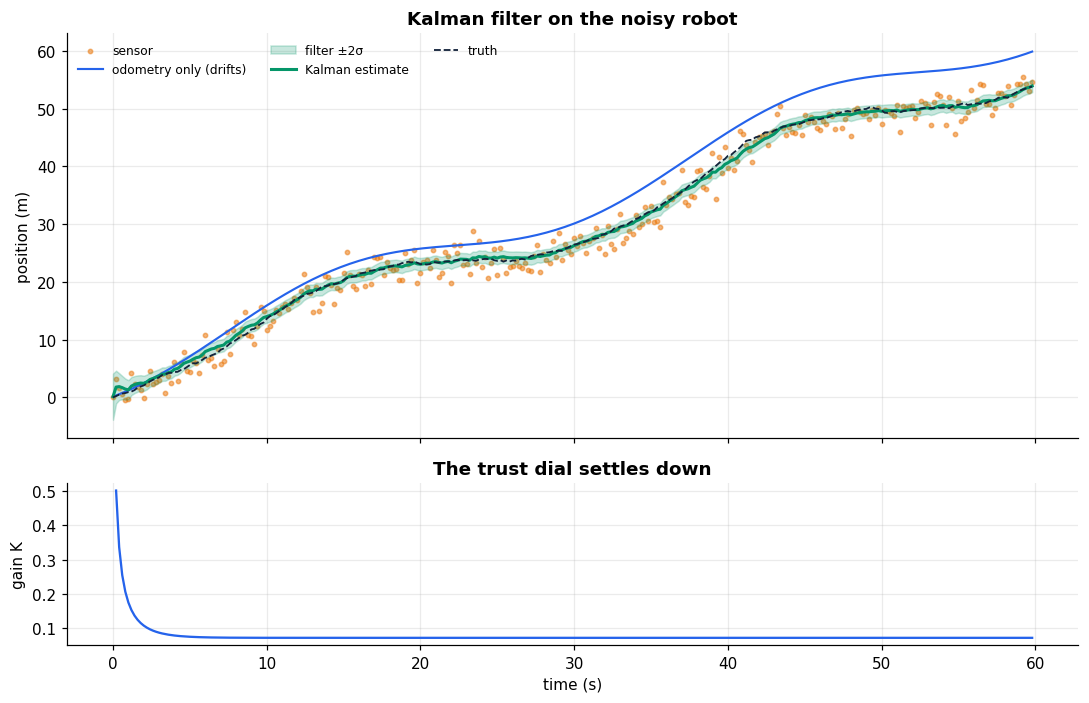

method                   RMSE (m)
raw sensor                   1.86
odometry only                4.14
moving average (k=5)         1.04
KALMAN FILTER                0.51

Truth inside the ±2σ band 95% of the time (a calibrated filter gives about 95%).


In [15]:
def run_kf1d(z, u, Q, R, x0=None, P0=None):
    """Run the 1-D Kalman filter over a full sequence of measurements.

    Args:
        z: 1-D array of measurements.
        u: 1-D array of commanded motions, aligned with `z` (`u[0]` unused).
        Q: Process noise variance (assumed constant).
        R: Measurement noise variance (assumed constant).
        x0: Initial state estimate. Defaults to `z[0]` if not given.
        P0: Initial estimate variance. Defaults to `R` if not given.

    Returns:
        dict: Per-step arrays `x`, `P`, `K`, `nu`, `S` (state, variance,
        Kalman gain, innovation, innovation variance), one value per input
        step.
    """
    n = len(z)
    x = z[0] if x0 is None else x0
    P = R if P0 is None else P0
    xs, Ps = np.zeros(n), np.zeros(n)
    Ks, nus, Ss = np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan)
    xs[0], Ps[0] = x, P
    for k in range(1, n):
        x, P = kf1d_predict(x, P, u[k], Q)
        x, P, K, nu, S = kf1d_update(x, P, z[k], R)
        xs[k], Ps[k], Ks[k], nus[k], Ss[k] = x, P, K, nu, S
    return dict(x=xs, P=Ps, K=Ks, nu=nus, S=Ss)

Q_TRUE, R_TRUE = Q_SD_TRUE ** 2, R_SD_TRUE ** 2
res = run_kf1d(z, u, Q_TRUE, R_TRUE)
x_odo = z[0] + np.concatenate([[0], np.cumsum(u[1:])])        # odometry only, no sensor

fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, gridspec_kw=dict(height_ratios=[3, 1.2]))
sd = np.sqrt(res["P"])
a1.scatter(t, z, s=8, color=ORANGE, alpha=.55, label="sensor")
a1.plot(t, x_odo, color=BLUE, lw=1.4, label="odometry only (drifts)")
a1.fill_between(t, res["x"] - 2 * sd, res["x"] + 2 * sd, color=GREEN, alpha=.22, label="filter ±2σ")
a1.plot(t, res["x"], color=GREEN, lw=2, label="Kalman estimate")
a1.plot(t, x_true, color=INK, lw=1.2, ls="--", label="truth")
a1.set(ylabel="position (m)", title="Kalman filter on the noisy robot"); a1.legend(ncol=3, fontsize=8)
a2.plot(t[1:], res["K"][1:], color=BLUE); a2.set(xlabel="time (s)", ylabel="gain K", title="The trust dial settles down")
plt.tight_layout(); plt.show()

inside = np.mean(np.abs(res["x"] - x_true) <= 2 * sd)
print(f"{'method':<24}{'RMSE (m)':>9}")
for name, est in [("raw sensor", z), ("odometry only", x_odo),
                  (f"moving average (k={k_best})", moving_average(z, k_best)), ("KALMAN FILTER", res["x"])]:
    print(f"{name:<24}{rmse(est, x_true):>9.2f}")
print(f"\nTruth inside the ±2σ band {inside:.0%} of the time (a calibrated filter gives about 95%).")

Hãy nhìn biểu đồ phía trên: đường xanh lá mượt như odometry nhưng không bao giờ trôi dạt như đường xanh dương, và dải tin cậy (band) thì mỏng. **Hãy phóng to vào một bước đơn lẻ** để xem *tại sao*:

C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


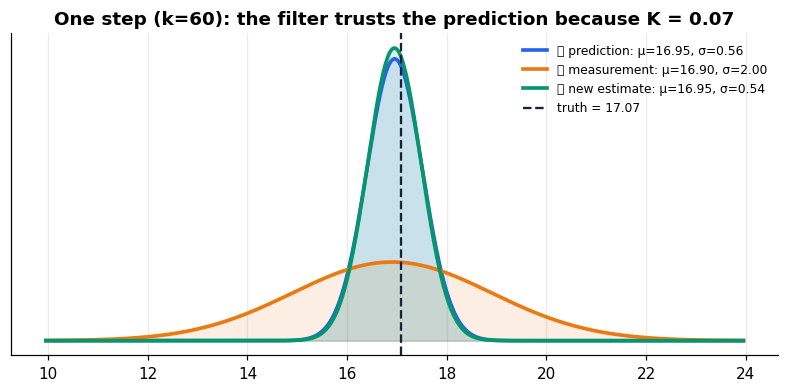

In [16]:
k = 60
x_prev, P_prev = res["x"][k - 1], res["P"][k - 1]
x_p, P_p = kf1d_predict(x_prev, P_prev, u[k], Q_TRUE)
x_n, P_n, K, nu, S = kf1d_update(x_p, P_p, z[k], R_TRUE)

xs_ = np.linspace(x_p - 7, x_p + 7, 700)
fig, ax = plt.subplots(figsize=(9, 3.8))
for mu, var, c, lab in [(x_p, P_p, BLUE, "🔵 prediction"), (z[k], R_TRUE, ORANGE, "🟠 measurement"), (x_n, P_n, GREEN, "🟢 new estimate")]:
    y = gaussian_pdf(xs_, mu, var)
    ax.plot(xs_, y, color=c, lw=2.4, label=f"{lab}: μ={mu:.2f}, σ={np.sqrt(var):.2f}"); ax.fill_between(xs_, y, color=c, alpha=.12)
ax.axvline(x_true[k], color=INK, ls="--", label=f"truth = {x_true[k]:.2f}")
ax.set_title(f"One step (k={k}): the filter trusts the prediction because K = {K:.2f}"); ax.set_yticks([]); ax.legend(fontsize=8)
plt.show()

### ▶️ Bài tập 3.2 · Độ lợi (gain) ổn định ở đâu? (đã điền sẵn, không chấm)
Biểu đồ trên cho thấy K nhanh chóng ổn định về một hằng số, gọi là **độ lợi trạng thái ổn định (steady-state gain)**. Dùng các con số Q = 0.0225 và R = 4, hãy tính xem bộ lọc thiên về phía nào *trước khi* chạy cell tiếp theo. Đoạn code sau đó sẽ tính nó bằng cách lặp đệ quy phương sai (covariance) của chính bộ lọc (không cần dữ liệu nào cả!). Hàm đã điền sẵn; chạy cell kế tiếp để xem K.


In [17]:
def steady_state_gain(Q, R, iters=500):
    """Iterate the predict/update variance recursion to steady state.

    Args:
        Q: Process noise variance.
        R: Measurement noise variance.
        iters: Number of predict/update cycles to run (large enough to
            converge).

    Returns:
        float: The Kalman gain `K` the filter settles to once its
        uncertainty stops changing from one step to the next.
    """
    P = R
    for _ in range(iters):
        P_pred = P + Q
        K = P_pred / (P_pred + R)
        P = (1 - K) * P_pred
    return K


In [18]:
K_ss = steady_state_gain(Q_TRUE, R_TRUE)
print(f"steady-state K = {K_ss:.3f}   |   simulated K at the end = {res['K'][-1]:.3f}")
assert np.isclose(K_ss, res["K"][-1], atol=1e-3), "should match the simulated gain"
print(f"✅ K ≈ {K_ss:.2f}: each update moves the estimate only {K_ss:.0%} of the way toward the sensor")
print("   -> the filter mostly trusts its prediction, because the sensor (σ=2 m) is much noisier than the motion (σ=0.15 m).")

steady-state K = 0.072   |   simulated K at the end = 0.072
✅ K ≈ 0.07: each update moves the estimate only 7% of the way toward the sensor
   -> the filter mostly trusts its prediction, because the sensor (σ=2 m) is much noisier than the motion (σ=0.15 m).


> ### 💡 Nhận định (Insight)
> * K **không phải** là một hằng số do bạn chọn. Nó được tính từ tỉ lệ giữa "dự đoán không chắc chắn đến mức nào" và "cảm biến không chắc chắn đến mức nào".
> * Phương sai (covariance) P không bao giờ nhìn vào dữ liệu thực tế. Đó là một *lời hứa* về độ chính xác, chỉ phụ thuộc vào Q, R và tần suất lấy mẫu của cảm biến. Đó là lý do bạn có thể dự đoán hiệu năng của bộ lọc trước cả khi xây dựng robot.

---
## Phần 4 · Tinh chỉnh Q và R, và tinh chỉnh không cần ground truth (giá trị thật) (10 phút · chạy để xem, không chấm)
🎯 **Mục tiêu:** xem một bộ lọc bị chỉnh sai trông như thế nào, sau đó học thủ thuật mà các kỹ sư dùng khi **không có đường giá trị thật (ground truth)** để so sánh.

Ở Phần 3, ta đã cho bộ lọc biết Q và R *thật*. Trong đời thực bạn phải tự đoán chúng. Hành vi của bộ lọc phụ thuộc vào **tỉ lệ** giữa hai giá trị này:

* **Q quá nhỏ** → "mô hình chuyển động của tôi hoàn hảo" → K co lại → bộ lọc bỏ qua cảm biến và **trôi dạt (drift)**.
* **Q quá lớn** → "mô hình chuyển động của tôi vô dụng" → K tăng lên → bộ lọc chỉ đơn giản sao chép cảm biến nhiễu và **rung giật (jittery)**.


### 🔮 Dự đoán trước
Bên dưới ta chạy cùng dữ liệu với Q_sd = 0.01, 0.15 và 1.0 (R giữ nguyên). Cái nào bị trôi dạt, cái nào rung giật, và cái nào có sai số thấp nhất?

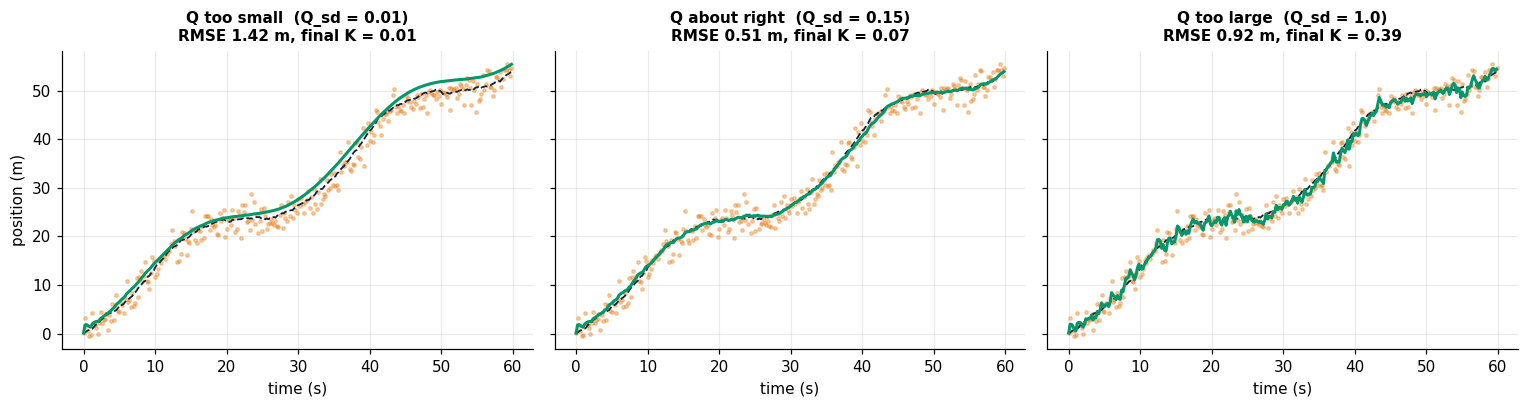

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, q_sd, label in zip(axs, [0.01, 0.15, 1.0], ["Q too small", "Q about right", "Q too large"]):
    r_ = run_kf1d(z, u, q_sd ** 2, R_TRUE)
    ax.scatter(t, z, s=5, color=ORANGE, alpha=.35)
    ax.plot(t, x_true, color=INK, lw=1.2, ls="--")
    ax.plot(t, r_["x"], color=GREEN, lw=2)
    ax.set_title(f"{label}  (Q_sd = {q_sd})\nRMSE {rmse(r_['x'], x_true):.2f} m, final K = {r_['K'][-1]:.2f}", fontsize=10)
    ax.set_xlabel("time (s)")
axs[0].set_ylabel("position (m)")
plt.tight_layout(); plt.show()

Bây giờ là một bản đồ của *mọi* tổ hợp Q và R giả định. Ngôi sao đánh dấu các giá trị thật.

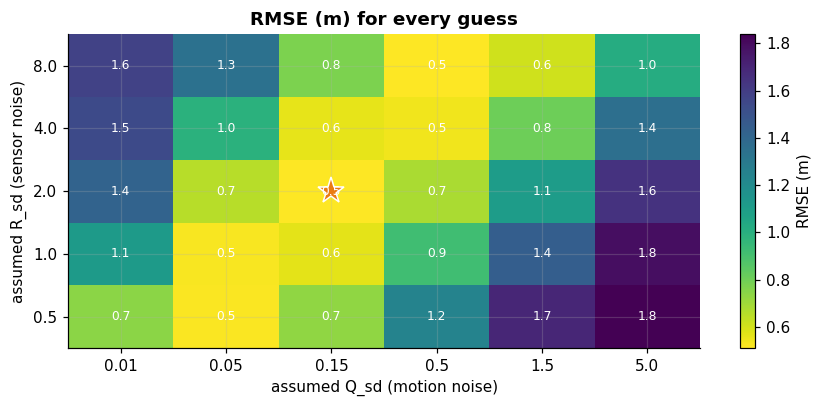

The valley is a diagonal band: what matters is the RATIO Q/R, not the absolute values.


In [20]:
q_grid = np.array([0.01, 0.05, 0.15, 0.5, 1.5, 5.0])
r_grid = np.array([0.5, 1.0, 2.0, 4.0, 8.0])
heat = np.array([[rmse(run_kf1d(z, u, q ** 2, r ** 2)["x"], x_true) for q in q_grid] for r in r_grid])

fig, ax = plt.subplots(figsize=(8, 3.8))
im = ax.imshow(heat, cmap="viridis_r", aspect="auto", origin="lower")
ax.set_xticks(range(len(q_grid)), [str(q) for q in q_grid]); ax.set_yticks(range(len(r_grid)), [str(r) for r in r_grid])
ax.set(xlabel="assumed Q_sd (motion noise)", ylabel="assumed R_sd (sensor noise)", title="RMSE (m) for every guess")
for i in range(len(r_grid)):
    for j in range(len(q_grid)):
        ax.text(j, i, f"{heat[i, j]:.1f}", ha="center", va="center", color="white", fontsize=8)
ax.plot([int(np.argmin(abs(q_grid - Q_SD_TRUE)))], [int(np.argmin(abs(r_grid - R_SD_TRUE)))], "*", color=ORANGE, ms=18, mec="white")   # the truth
plt.colorbar(im, label="RMSE (m)"); plt.tight_layout(); plt.show()
print("The valley is a diagonal band: what matters is the RATIO Q/R, not the absolute values.")

### Vấn đề lớn: thường thì bạn không có giá trị thật
RMSE (sai số căn quân phương) cần vị trí thật, điều mà một robot thực tế không bao giờ có. Thủ thuật tiêu chuẩn là dùng **đổi mới (innovation)** ν = z − x⁻ ("sự bất ngờ" của bộ lọc) cùng với phương sai dự đoán S của nó.

Nếu bộ lọc trung thực, *bình phương đổi mới đã chuẩn hóa (normalised innovation squared)* **NIS = ν² / S** sẽ có trung bình xấp xỉ **1**:
* NIS trung bình ≫ 1 → sự bất ngờ lớn hơn những gì bộ lọc kỳ vọng (bộ lọc **quá tự tin**; Q hoặc R quá nhỏ)
* NIS trung bình ≪ 1 → sự bất ngờ nhỏ hơn kỳ vọng (bộ lọc **thiếu tự tin**; Q hoặc R quá lớn)

NIS là một thống kê *nhiễu*: trung bình của N giá trị ν²/S có độ phân tán khoảng √(2/N). Log 300 mẫu của chúng ta quá ngắn để kiểm định rõ ràng, nên cell bên dưới mô phỏng một **log dài 3000 bước** (một robot thật có thể ghi log hàng giờ).

### ▶️ Bài tập 4.1 · Tinh chỉnh mà không cần ground truth (đã điền sẵn, không chấm)
1. Hàm `mean_nis(res)` đã điền sẵn: trung bình của ν²/S trên toàn bộ quá trình chạy (`res["nu"]` và `res["S"]` bắt đầu bằng `nan`, nên hãy dùng `np.nanmean`).
2. Hàm `pick_q_by_nis(z, u, R, candidates)` đã điền sẵn: chạy bộ lọc với từng ứng viên Q_sd và trả về ứng viên có NIS trung bình **gần 1 nhất**. Hàm này không bao giờ nhìn vào giá trị thật.


In [21]:
# a long log (3000 steps). The truth is only used LATER, to grade the NIS trick, never inside the trick itself
_, x_L, z_L, u_L = simulate_1d(n=3000, dt=DT, q_sd=Q_SD_TRUE, r_sd=R_SD_TRUE, seed=21)
print(f"long log: {len(z_L)} samples, expected spread of the mean NIS ≈ ±{np.sqrt(2 / len(z_L)):.2f}")

long log: 3000 samples, expected spread of the mean NIS ≈ ±0.03


In [22]:
def mean_nis(res):
    """Compute the mean Normalized Innovation Squared (NIS) of a run.

    Args:
        res: A result dict as returned by `run_kf1d`, containing `nu`
            (innovations) and `S` (innovation variances).

    Returns:
        float: The average of `nu**2 / S` across all steps. A well-tuned
        filter has mean NIS close to 1.
    """
    return float(np.nanmean(res["nu"] ** 2 / res["S"]))

def pick_q_by_nis(z, u, R, candidates):
    """Pick the process-noise std whose filter NIS is closest to 1.

    Args:
        z: 1-D array of measurements.
        u: 1-D array of commanded motions.
        R: Measurement noise variance.
        candidates: Iterable of candidate values for the process noise
            standard deviation `Q_sd` to try.

    Returns:
        The candidate `Q_sd` whose resulting filter has mean NIS closest
        to 1, selected WITHOUT ever looking at the ground truth.
    """
    scores = [abs(mean_nis(run_kf1d(z, u, q ** 2, R)) - 1.0) for q in candidates]
    return candidates[int(np.argmin(scores))]


In [23]:
def check_nis():
    """Verify that NIS-based tuning picks a reasonable process noise.

    Raises:
        AssertionError: If the correctly-tuned filter's mean NIS is not
            close to 1, or if NIS-based selection does not land within a
            factor of ~2 of the true process noise.
    """
    r_ = run_kf1d(z_L, u_L, Q_TRUE, R_TRUE)
    assert 0.85 < mean_nis(r_) < 1.15, f"a correctly tuned filter should have mean NIS ≈ 1, got {mean_nis(r_):.2f}"
    best = pick_q_by_nis(z_L, u_L, R_TRUE, [0.02, 0.05, 0.1, 0.15, 0.3, 0.6, 1.0])
    assert 0.1 <= best <= 0.3, f"picked Q_sd = {best}; the truth is 0.15 (NIS should get you within a factor of ~2)"
    print(f"✅ Exercise 4.1 passed: NIS picked Q_sd = {best} (truth: {Q_SD_TRUE}) without ever seeing the truth")
check_nis()

✅ Exercise 4.1 passed: NIS picked Q_sd = 0.15 (truth: 0.15) without ever seeing the truth


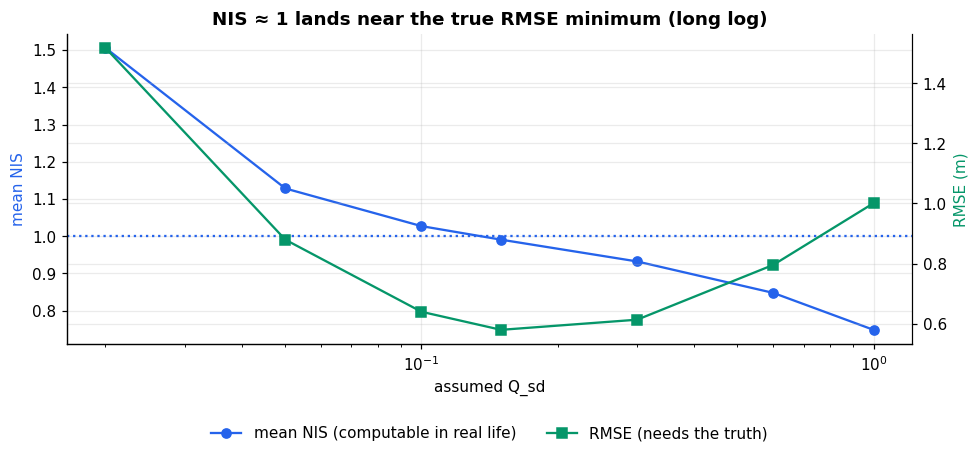

In [24]:
cands = np.array([0.02, 0.05, 0.1, 0.15, 0.3, 0.6, 1.0])
nis = [mean_nis(run_kf1d(z_L, u_L, q ** 2, R_TRUE)) for q in cands]
err = [rmse(run_kf1d(z_L, u_L, q ** 2, R_TRUE)["x"], x_L) for q in cands]

fig, ax = plt.subplots(figsize=(9, 3.8)); ax2 = ax.twinx()
ax.plot(cands, nis, "o-", color=BLUE, label="mean NIS (computable in real life)")
ax.axhline(1, color=BLUE, ls=":"); ax.set_xscale("log"); ax.set_ylabel("mean NIS", color=BLUE); ax.set_xlabel("assumed Q_sd")
ax2.plot(cands, err, "s-", color=GREEN, label="RMSE (needs the truth)"); ax2.set_ylabel("RMSE (m)", color=GREEN); ax2.spines["right"].set_visible(True)
ax.set_title("NIS ≈ 1 lands near the true RMSE minimum (long log)"); fig.legend(loc="upper center", bbox_to_anchor=(.5, .0), ncol=2)
plt.tight_layout(); plt.show()

### 🎛️ Tùy chọn · tự tinh chỉnh
Thay đổi Q và R rồi quan sát K và sai số. Bạn có thể tìm ra điểm tối ưu (sweet spot) bằng mắt thường không?

In [25]:
try:
    from ipywidgets import interact, FloatLogSlider
    def _tune(Q_sd=0.15, R_sd=2.0):
        """Interactive callback: refit and replot the 1-D filter from sliders.

        Args:
            Q_sd: Process noise standard deviation, from the slider.
            R_sd: Measurement noise standard deviation, from the slider.

        Returns:
            None: Displays a new Matplotlib figure with RMSE/gain/NIS in the title.
        """
        r_ = run_kf1d(z, u, Q_sd ** 2, R_sd ** 2)
        fig, ax = plt.subplots(figsize=(9, 3.4))
        ax.scatter(t, z, s=5, color=ORANGE, alpha=.35); ax.plot(t, x_true, color=INK, ls="--", lw=1.1)
        ax.plot(t, r_["x"], color=GREEN, lw=2)
        ax.set_title(f"RMSE {rmse(r_['x'], x_true):.2f} m | final K {r_['K'][-1]:.2f} | mean NIS {mean_nis(r_):.2f}"); plt.show()
    interact(_tune, Q_sd=FloatLogSlider(value=.15, base=10, min=-2, max=.5, step=.05), R_sd=FloatLogSlider(value=2, base=10, min=-.5, max=1.2, step=.05))
except ImportError:
    print("ipywidgets is not installed, skipping the interactive demo")

interactive(children=(FloatLogSlider(value=0.15, description='Q_sd', max=0.5, min=-2.0, step=0.05), FloatLogSl…

> ### 💡 Nhận định (Insight)
> * Q và R là **những phát biểu trung thực về mức độ nghi ngờ**, không phải những núm vặn ma thuật. Hãy đo R từ datasheet của cảm biến hoặc một bài kiểm tra khi đứng yên. Tinh chỉnh Q cho đến khi **NIS ≈ 1** và đường đi (track) mượt mà.
> * ⚠️ **Cạm bẫy (Pitfall):** NIS ≈ 1 chỉ cho thấy bộ lọc *nhất quán (consistent)*, không có nghĩa là nó *tối ưu*. NIS thay đổi chậm theo Q (để ý đường cong khá phẳng), nên nó chỉ thu hẹp Q về một *khoảng (band)*, và chỉ đáng tin trên một **log dài**. Q và R cũng có thể đánh đổi một phần cho nhau, nên luôn kiểm tra lại bằng một biểu đồ.

---
## Sang Phần 5
Một câu hỏi trước khi tự code: *cảm biến của robot chúng ta báo cáo **vị trí**, nhưng một chiếc xe thật cũng cần **vận tốc**. Liệu một bộ lọc có thể tự tìm ra vận tốc dù không cảm biến nào đo nó không?* Phần 5 sẽ trả lời câu hỏi đó.


---
## Phần 5 · Nhiều chiều: Kalman filter dạng ma trận (25 phút · tự code, có chấm)
🎯 **Mục tiêu:** nâng cấp lên một phương tiện 2 chiều (2-D) và xem bộ lọc **tự khám phá ra vận tốc, thứ mà không cảm biến nào từng đo được**.

Hệ thống thực tế có nhiều đại lượng cùng lúc, nên các con số trở thành vector và ma trận. *Ý tưởng* thì không thay đổi gì cả. Đây là bảng đối chiếu thuật ngữ:

| Lab 1 chiều | Dạng ma trận | Ý nghĩa |
|:--:|:--:|:--|
| x | **x** = [x, y, vₓ, v_y]ᵀ | trạng thái (state): *những gì ta muốn biết* (chỉ x và y được đo!) |
| P | **P** (4×4) | độ bất định, giờ có thêm tương quan (correlation) (vị trí và vận tốc liên kết với nhau) |
| "+ u" | **F** | mô hình chuyển động: x ← x + vₓ·dt, và vận tốc giữ nguyên |
| Q | **Q** | nhiễu quá trình (process noise): *xe có thể tăng tốc hoặc phanh* |
| z | **z**, cùng với **H** | cảm biến chỉ thấy được vị trí: z = H·x |
| R | **R** | nhiễu phép đo (measurement noise) |
| K = P⁻/(P⁻+R) | **K = P⁻Hᵀ (H P⁻ Hᵀ + R)⁻¹** | độ lợi (gain), giờ là một ma trận |

Dự đoán (Predict): **x⁻ = F x**, **P⁻ = F P Fᵀ + Q**
Cập nhật (Update): **ν = z − H x⁻**, **S = H P⁻ Hᵀ + R**, **K = P⁻ Hᵀ S⁻¹**, **x = x⁻ + K ν**, **P = (I − K H) P⁻**


**Kịch bản của chúng ta:** một chiếc xe chạy theo hình số 8 trong 60 giây (tăng tốc lên khoảng 8 m/s, với các khúc cua mà bộ lọc *không* biết trước). Một cảm biến báo cáo (x, y) ở tần số 10 Hz với nhiễu σ = 3 m. Bộ lọc giả định "vận tốc xấp xỉ không đổi".

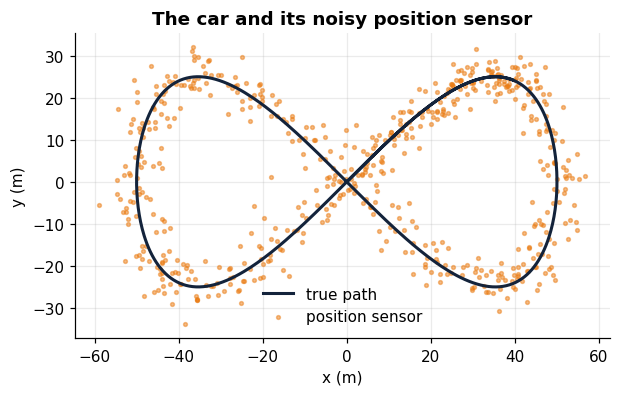

In [26]:
def truth_state(t):
    """Compute the ground-truth state of a car driving a figure-8 path.

    Args:
        t: Time (scalar or array-like), in seconds.

    Returns:
        numpy.ndarray: Array of shape `(len(t), 4)` with columns
        `[x, y, vx, vy]`, the true position and velocity at each time.
    """
    t = np.atleast_1d(np.asarray(t, float))
    x, y = 50 * np.sin(0.12 * t), 25 * np.sin(0.24 * t)
    vx, vy = 6.0 * np.cos(0.12 * t), 6.0 * np.cos(0.24 * t)
    return np.stack([x, y, vx, vy], axis=1)

T_END, DT2, SIG_POS = 60.0, 0.1, 3.0
t2 = np.arange(0, T_END, DT2)
S2 = truth_state(t2)
rng2 = np.random.default_rng(3)
z2 = S2[:, :2] + rng2.normal(0, SIG_POS, (len(t2), 2))        # position-only measurements

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(S2[:, 0], S2[:, 1], color=INK, lw=2, label="true path"); ax.scatter(z2[:, 0], z2[:, 1], s=6, color=ORANGE, alpha=.5, label="position sensor")
ax.set(aspect="equal", xlabel="x (m)", ylabel="y (m)", title="The car and its noisy position sensor"); ax.legend(); plt.show()

### ✏️ Bài tập 5.1 · Các ma trận mô hình (8 phút)
* `make_F(dt)`: một ma trận 4×4 thực hiện x ← x + vₓ·dt và y ← y + v_y·dt, đồng thời giữ nguyên vận tốc (bắt đầu từ `np.eye(4)`).
* `make_H()`: một ma trận 2×4 trích ra x và y từ trạng thái (state).

(`make_Q`, nhiễu "gia tốc ngẫu nhiên (random acceleration)" tiêu chuẩn, đã được cho sẵn.)


In [27]:
def make_F(dt):
    """Build the constant-velocity state transition matrix.

    Args:
        dt: Time step, in seconds.

    Returns:
        numpy.ndarray: 4x4 matrix `F` such that `F @ [x, y, vx, vy]`
        advances position by velocity * dt and leaves velocity unchanged.
    """
    F = np.eye(4)
    F[0, 2] = dt
    F[1, 3] = dt
    return F

def make_H():
    """Build the measurement matrix for a position-only sensor.

    Returns:
        numpy.ndarray: 2x4 matrix `H` that extracts `[x, y]` from the
        4-element state `[x, y, vx, vy]`.
    """
    H = np.zeros((2, 4))
    H[0, 0] = 1.0
    H[1, 1] = 1.0
    return H

def make_Q(dt, q):
    """Build the constant-velocity process noise covariance matrix.

    Models the assumption that the car may accelerate randomly with
    strength `q` (units of m^2/s^3), using the standard discretized
    white-noise-acceleration model.

    Args:
        dt: Time step, in seconds.
        q: Process noise strength (acceleration power spectral density).

    Returns:
        numpy.ndarray: 4x4 process noise covariance matrix `Q`, block
        diagonal over the (x, vx) and (y, vy) pairs.
    """
    blk = q * np.array([[dt ** 3 / 3, dt ** 2 / 2], [dt ** 2 / 2, dt]])
    Q = np.zeros((4, 4))
    Q[np.ix_([0, 2], [0, 2])] = blk
    Q[np.ix_([1, 3], [1, 3])] = blk
    return Q

In [28]:
def check_matrices():
    """Verify `make_F` and `make_H` behave as documented.

    Raises:
        AssertionError: If `F` does not advance position by velocity * dt,
            or if `H` does not extract `[x, y]` from the state.
    """
    x = np.array([10., 20., 3., -2.])
    assert np.allclose(make_F(0.5) @ x, [11.5, 19.0, 3., -2.]), "F should move the position by velocity*dt and keep the velocity"
    assert np.allclose(make_H() @ x, [10., 20.]), "H should extract [x, y]"
    print("✅ Exercise 5.1 passed")
check_matrices()

✅ Exercise 5.1 passed


### ✏️ Bài tập 5.2 · Lớp (class) Kalman filter dạng ma trận (15 phút)
Cài đặt các phương trình ma trận từ bảng ở trên. Hàm `update` nên trả về `(y, S, K)` (đổi mới - innovation, phương sai của nó, và độ lợi - gain). Dùng `@` cho phép nhân ma trận và `np.linalg.inv` cho nghịch đảo.

**Đối chiếu chéo với Phần 3:** cell kiểm tra sẽ chạy class của bạn trên robot 1 chiều (với các ma trận 1×1) và yêu cầu **kết quả giống hệt** `run_kf1d`. Bộ lọc dạng ma trận *chính là* bộ lọc vô hướng (scalar), chỉ là tổng quát hóa.


In [29]:
class KalmanFilter:
    """A standard linear Kalman filter over an arbitrary-dimension state.

    Attributes:
        x: Current state estimate (1-D numpy array).
        P: Current state estimate covariance (2-D numpy array).
    """
    def __init__(self, x0, P0):
        """Initialize the filter with a starting state and covariance.

        Args:
            x0: Initial state estimate.
            P0: Initial state covariance.
        """
        self.x = np.array(x0, dtype=float)      # state mean
        self.P = np.array(P0, dtype=float)      # state covariance

    def predict(self, F, Q):
        """Advance the state estimate through the process model.

        Args:
            F: State transition matrix for this time step.
            Q: Process noise covariance for this time step.

        Returns:
            None: Updates `self.x` and `self.P` in place.
        """
        self.x = F @ self.x
        self.P = F @ self.P @ F.T + Q

    def update(self, z, H, R):
        """Correct the state estimate using a new measurement.

        Args:
            z: Measurement vector.
            H: Measurement matrix mapping state to measurement space.
            R: Measurement noise covariance.

        Returns:
            tuple: `(y, S, K)` -- the innovation, innovation covariance, and
            Kalman gain used for this update. `self.x` and `self.P` are
            updated in place.
        """
        y = z - H @ self.x
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(len(self.x)) - K @ H) @ self.P
        return y, S, K

In [30]:
def check_kf_class():
    # 1-D robot through the matrix class must equal the scalar filter from Part 3
    """Verify the matrix `KalmanFilter` reproduces the scalar 1-D filter.

    Also sanity-checks that a position-only measurement correctly inflates
    the Kalman gain on a highly uncertain velocity component.

    Raises:
        AssertionError: If the matrix filter disagrees with `run_kf1d`, or
            if the velocity gain is not large for a very uncertain prior.
    """
    ref = run_kf1d(z, u, Q_TRUE, R_TRUE)
    kf = KalmanFilter([z[0]], [[R_TRUE]])
    xs = [z[0]]
    for k in range(1, len(z)):
        kf.predict(np.array([[1.0]]), np.array([[Q_TRUE]]))
        kf.x = kf.x + u[k]                                   # odometry input, same as "x + u"
        kf.update(np.array([z[k]]), np.array([[1.0]]), np.array([[R_TRUE]]))
        xs.append(kf.x[0])
    assert np.allclose(xs, ref["x"], atol=1e-9), "matrix filter and scalar filter disagree"
    # a 2-state sanity check: position measurement reveals velocity through correlation
    kf = KalmanFilter([0, 0], np.diag([1., 100.]))
    kf.predict(np.array([[1, 1.], [0, 1]]), np.zeros((2, 2)))
    _, _, K = kf.update(np.array([5.0]), np.array([[1., 0.]]), np.array([[1.0]]))
    assert K.shape == (2, 1) and K[1, 0] > 0.5, "the velocity part of K should be large (velocity is very uncertain)"
    print("✅ Exercise 5.2 passed: the matrix filter reproduces the 1-D filter exactly")
check_kf_class()

✅ Exercise 5.2 passed: the matrix filter reproduces the 1-D filter exactly


Bây giờ hãy chạy nó trên chiếc xe chạy hình số 8. Ta bắt đầu với **không hề biết gì về vận tốc** (vận tốc ban đầu bằng 0, nhưng với độ bất định rất lớn là ±10 m/s).

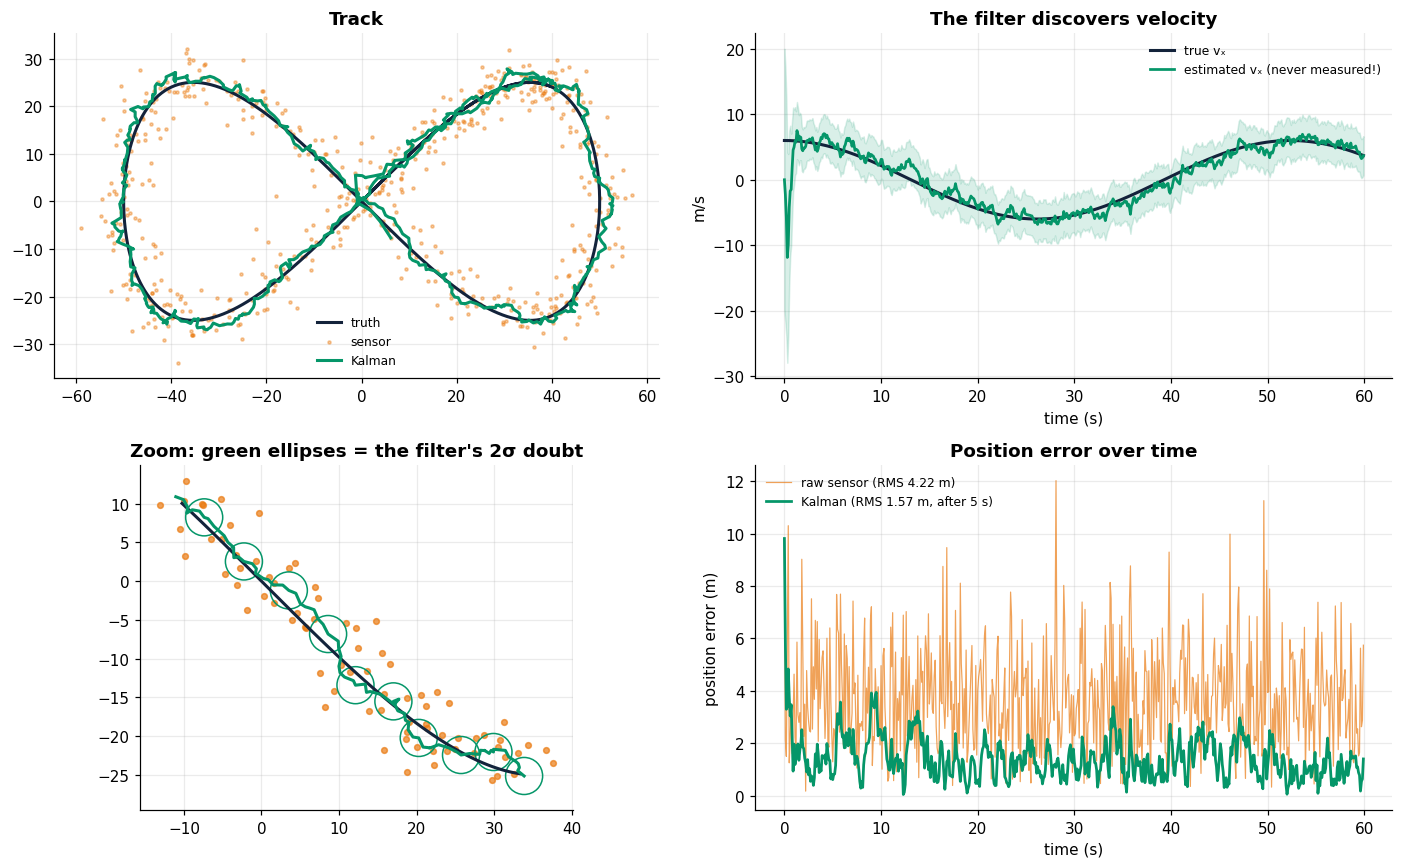

Position RMSE: sensor 4.22 m  ->  Kalman 1.57 m
Velocity RMSE: 1.63 m/s  (no sensor measures velocity!)
✅ the filter beats the sensor and recovered the velocity


In [31]:
F, H = make_F(DT2), make_H()
Q_CAR = 2.0                                  # how much the car may accelerate (found by trying a few values; see the challenge below)
Q2, R2 = make_Q(DT2, q=Q_CAR), np.diag([SIG_POS ** 2] * 2)
x0 = np.array([z2[0, 0], z2[0, 1], 0.0, 0.0])
P0 = np.diag([SIG_POS ** 2, SIG_POS ** 2, 10.0 ** 2, 10.0 ** 2])

kf = KalmanFilter(x0, P0)
est, covs = [x0.copy()], [P0.copy()]
for k in range(1, len(t2)):
    kf.predict(F, Q2)
    kf.update(z2[k], H, R2)
    est.append(kf.x.copy()); covs.append(kf.P.copy())
est, covs = np.array(est), np.array(covs)

fig, axs = plt.subplots(2, 2, figsize=(13, 8))
ax = axs[0, 0]
ax.plot(S2[:, 0], S2[:, 1], color=INK, lw=2, label="truth"); ax.scatter(z2[:, 0], z2[:, 1], s=4, color=ORANGE, alpha=.4, label="sensor")
ax.plot(est[:, 0], est[:, 1], color=GREEN, lw=2, label="Kalman"); ax.set(aspect="equal", title="Track"); ax.legend(fontsize=8)

ax = axs[0, 1]
ax.plot(t2, S2[:, 2], color=INK, lw=2, label="true vₓ"); ax.plot(t2, est[:, 2], color=GREEN, lw=1.8, label="estimated vₓ (never measured!)")
ax.fill_between(t2, est[:, 2] - 2 * np.sqrt(covs[:, 2, 2]), est[:, 2] + 2 * np.sqrt(covs[:, 2, 2]), color=GREEN, alpha=.15)
ax.set(xlabel="time (s)", ylabel="m/s", title="The filter discovers velocity"); ax.legend(fontsize=8)

ax = axs[1, 0]
sel = (t2 > 20) & (t2 < 28)
ax.plot(S2[sel, 0], S2[sel, 1], color=INK, lw=2); ax.scatter(z2[sel, 0], z2[sel, 1], s=14, color=ORANGE, alpha=.7)
ax.plot(est[sel, 0], est[sel, 1], color=GREEN, lw=2)
for k in np.where(sel)[0][::8]:
    cov_ellipse(ax, est[k, :2], covs[k, :2, :2], n_std=2, fill=False, ec=GREEN, lw=1)
ax.set(aspect="equal", title="Zoom: green ellipses = the filter's 2σ doubt")

ax = axs[1, 1]
e_raw = np.linalg.norm(z2 - S2[:, :2], axis=1); e_kf = np.linalg.norm(est[:, :2] - S2[:, :2], axis=1)
ax.plot(t2, e_raw, color=ORANGE, lw=.8, alpha=.7, label=f"raw sensor (RMS {rmse(e_raw):.2f} m)")
ax.plot(t2, e_kf, color=GREEN, lw=1.8, label=f"Kalman (RMS {rmse(e_kf[50:]):.2f} m, after 5 s)")
ax.set(xlabel="time (s)", ylabel="position error (m)", title="Position error over time"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

v_err = np.linalg.norm(est[50:, 2:] - S2[50:, 2:], axis=1)
print(f"Position RMSE: sensor {rmse(e_raw):.2f} m  ->  Kalman {rmse(e_kf[50:]):.2f} m")
print(f"Velocity RMSE: {rmse(v_err):.2f} m/s  (no sensor measures velocity!)")
assert rmse(e_kf[50:]) < rmse(e_raw) * 0.7 and rmse(v_err) < 2.0
print("✅ the filter beats the sensor and recovered the velocity")

> 🏋️ **Thử thách (2 phút):** đổi `Q_CAR` thành 0.1 rồi chạy lại. Đường track xanh lá sai ở đâu, và tại sao? Sau đó thử với 20. (So sánh với Phần 4: câu chuyện y hệt, giờ ở dạng 2 chiều.)

### Tại sao vận tốc lại xuất hiện từ đâu không rõ?
Vị trí tại thời điểm *t* và vị trí tại thời điểm *t+dt* khác nhau đúng bằng vận tốc × dt. Ma trận **F** liên kết chúng với nhau, nên P hình thành các **tương quan (correlation)** giữa vị trí và vận tốc. Khi một phép đo vị trí sửa một đại lượng, bộ lọc cũng sửa đại lượng còn lại thông qua tương quan đó. Hãy nhìn vào bên trong:

In [32]:
P_now = covs[300]
print("Position-velocity correlation of x at t=30 s:", round(P_now[0, 2] / np.sqrt(P_now[0, 0] * P_now[2, 2]), 2))
print("(0 would mean unrelated; the filter's gain on velocity comes from this link)")

Position-velocity correlation of x at t=30 s: 0.69
(0 would mean unrelated; the filter's gain on velocity comes from this link)


> ### 💡 Nhận định (Insight)
> * **Trạng thái (state) ≠ phép đo (measurement).** Trạng thái chứa mọi thứ bạn cần để dự đoán tương lai. Cảm biến chỉ cần nhìn thấy *một phần* của nó.
> * ⚠️ **Cạm bẫy: mô hình không khớp (model mismatch).** Xe rẽ cua, nhưng bộ lọc giả định vận tốc không đổi. Nó chỉ xoay sở được vì **Q thừa nhận rằng mô hình có thể sai** (gia tốc ngẫu nhiên). Nếu đặt Q quá nhỏ, bộ lọc sẽ bị trễ khi vào cua, đây là lỗi kinh điển "bộ lọc làm mượt mất luôn cả pha chuyển động (manoeuvre)".

---
## Phần 6 · Hợp nhất xác suất (Probabilistic fusion): LiDAR + radar + camera (12 phút · tự code, có chấm)
🎯 **Mục tiêu:** hợp nhất ba cảm biến *khác nhau, bất đồng bộ (asynchronous)* thành một track (đường theo dõi) duy nhất và xem nó sống sót qua sương mù và tình trạng mất tín hiệu cảm biến.

Đây là một điều bất ngờ tuyệt đẹp: **hợp nhất (fusion) không cần toán học mới nào cả.** Mỗi cảm biến chỉ cần cung cấp `z`, `H` và `R` của riêng nó, và ta gọi `update()` một lần cho mỗi phép đo, theo đúng thứ tự thời gian. Giữa các phép đo, ta `predict()` tiến về phía trước theo khoảng thời gian đã trôi qua (một `dt` *biến thiên*).

| Cảm biến | Tần suất | σ vị trí | Còn cho biết thêm | Đặc điểm riêng |
|:--|:--:|:--:|:--|:--|
| 🟣 **LiDAR** | 10 Hz | **0.3 m** (sắc nét) | | bị mù trong sương mù |
| 🔵 **Radar** | 20 Hz | 1.5 m | **vận tốc**, σ = 0.3 m/s | nhìn xuyên qua sương mù được |
| 🔴 **Camera** | 30 Hz | 2.5 m (mơ hồ) | | bỏ lỡ 15% số khung hình |

Các cảm biến **không được đồng bộ hóa (synchronised)** (mỗi cảm biến có độ lệch đồng hồ riêng), đây là tình huống bình thường trên một chiếc xe thực tế.


In [33]:
SENSORS = {
    "LiDAR":  dict(rate=10, offset=0.000, pos_sd=0.30, vel_sd=None, drop=0.00, color="#7C3AED"),
    "Radar":  dict(rate=20, offset=0.013, pos_sd=1.50, vel_sd=0.30, drop=0.00, color="#0891B2"),
    "Camera": dict(rate=30, offset=0.021, pos_sd=2.50, vel_sd=None, drop=0.15, color="#DB2777"),
}

def make_measurements(sensors, T=T_END, seed=11, blackout=None, latency=None, stamp="capture"):
    """Simulate a multi-sensor measurement stream for the figure-8 car.

    Args:
        sensors: Dict of sensor name -> spec dict (rate, offset, pos_sd,
            vel_sd, drop, color), as in the module-level `SENSORS` dict.
        T: Total simulated duration, in seconds.
        seed: Seed for the random number generator, for reproducibility.
        blackout: Optional dict `{name: (t0, t1)}`; the named sensor
            produces no measurements during that time window.
        latency: Optional dict `{name: seconds}`; processing delay applied
            to the named sensor.
        stamp: `"capture"` to timestamp measurements at true capture time,
            or `"arrival"` to use the (delayed, incorrect) arrival time.

    Returns:
        list: Tuples `(timestamp, name, z, H, R)` sorted by timestamp, one
        per simulated measurement across all sensors.
    """
    rng = np.random.default_rng(seed)
    blackout, latency = blackout or {}, latency or {}
    out = []
    for name, s in sensors.items():
        for tc in np.arange(s["offset"], T, 1.0 / s["rate"]):                  # capture times
            if rng.random() < s["drop"]:
                continue
            if name in blackout and blackout[name][0] <= tc < blackout[name][1]:
                continue
            state = truth_state(tc)[0]
            if s["vel_sd"] is None:                                            # position-only sensor
                H, R = make_H(), np.diag([s["pos_sd"] ** 2] * 2)
                z = state[:2] + rng.normal(0, s["pos_sd"], 2)
            else:                                                              # position + velocity sensor
                H, R = np.eye(4), np.diag([s["pos_sd"] ** 2] * 2 + [s["vel_sd"] ** 2] * 2)
                z = state + rng.normal(0, np.sqrt(np.diag(R)))
            ts = tc + latency.get(name, 0.0) if stamp == "arrival" else tc
            out.append((ts, name, z, H, R))
    out.sort(key=lambda m: m[0])
    return out

meas = make_measurements(SENSORS)
print("measurements in 60 s:", {n: sum(m[1] == n for m in meas) for n in SENSORS})
print("first five (time, sensor):", [(round(float(m[0]), 3), m[1]) for m in meas[:5]])

measurements in 60 s: {'LiDAR': 600, 'Radar': 1200, 'Camera': 1505}
first five (time, sensor): [(0.0, 'LiDAR'), (0.013, 'Radar'), (0.021, 'Camera'), (0.054, 'Camera'), (0.063, 'Radar')]


### ✏️ Bài tập 6.1 · Vòng lặp hợp nhất (fusion loop) (12 phút)
Viết hàm `run_fusion(meas, q, x0, P0)`. Với mỗi phép đo `(ts, name, z, H, R)` **theo thứ tự thời gian**:
1. `dt = ts − t_prev`. Nếu `dt > 0`, **predict** (dự đoán) tiến về phía trước bằng `make_F(dt)` và `make_Q(dt, q)`.
2. **Update** (cập nhật) với `z`, `H`, `R` *của cảm biến đó*.
3. Ghi nhớ mốc thời gian (timestamp), và thêm `(ts, kf.x.copy(), kf.P.copy())` vào log.

Chú ý điều còn thiếu: **không hề có logic riêng cho từng loại cảm biến**, ngoại trừ `H` và `R` đi kèm theo mỗi phép đo.


In [34]:
def run_fusion(meas, q, x0, P0, t0=0.0):
    """Run a Kalman filter over a mixed, asynchronous multi-sensor stream.

    Args:
        meas: List of `(timestamp, name, z, H, R)` tuples, sorted by time
            (as returned by `make_measurements`).
        q: Process noise strength passed to `make_Q`.
        x0: Initial state estimate.
        P0: Initial state covariance.
        t0: Time of the initial state estimate.

    Returns:
        list: `(timestamp, x, P)` tuples logging the filter's state and
        covariance immediately after each measurement update.
    """
    kf = KalmanFilter(x0, P0)
    t_prev = t0
    log = []
    for ts, name, z, H, R in meas:
        dt = ts - t_prev
        if dt > 0:
            kf.predict(make_F(dt), make_Q(dt, q))
        kf.update(z, H, R)
        t_prev = ts
        log.append((ts, kf.x.copy(), kf.P.copy()))
    return log

In [35]:
def check_run_fusion():
    """Verify `run_fusion` tracks a LiDAR-only stream accurately.

    Raises:
        AssertionError: If the logged track has the wrong length, if a
            degenerate double-timestamp input breaks the filter, or if the
            tracking error is larger than expected.
    """
    lidar = make_measurements({"LiDAR": SENSORS["LiDAR"]}, seed=1)
    log = run_fusion(lidar, 0.5, np.zeros(4), np.diag([50. ** 2, 50. ** 2, 10. ** 2, 10. ** 2]))
    assert len(log) == len(lidar), "one log entry per measurement"
    ts = np.array([l[0] for l in log]); est = np.array([l[1] for l in log])
    err = np.linalg.norm(est[:, :2] - truth_state(ts)[:, :2], axis=1)
    assert rmse(err[50:]) < 0.35, f"LiDAR-only track error {rmse(err[50:]):.2f} m is too large; the raw sensor alone is ~0.42 m"
    # two measurements with the SAME timestamp (dt = 0) must not break anything
    log2 = run_fusion(lidar[:3] + [lidar[2]], 0.5, np.zeros(4), np.eye(4) * 10)
    assert len(log2) == 4 and np.all(np.isfinite(log2[-1][1]))
    print("✅ Exercise 6.1 passed")
check_run_fusion()

✅ Exercise 6.1 passed


Bây giờ hãy so sánh từng cảm biến **riêng lẻ** với track đã **hợp nhất (fused)**. Để công bằng, mọi track đều được lấy mẫu trên cùng một lưới đầu ra 10 Hz (sau 2 giây khởi động), ngoại suy (extrapolate) mỗi ước lượng tới thời điểm đầu ra bằng ước lượng vận tốc riêng của nó.

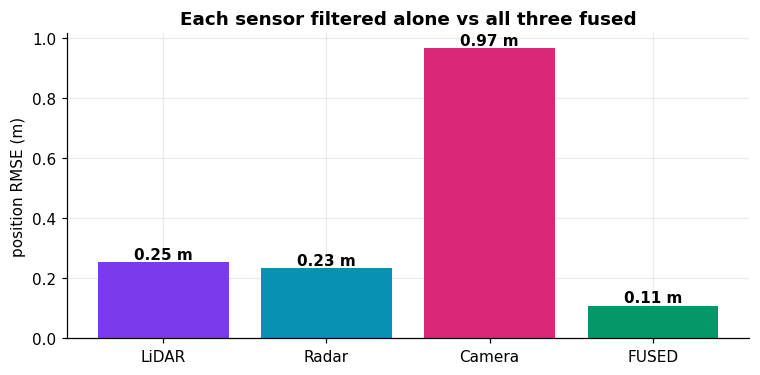

LiDAR    0.254 m
Radar    0.234 m
Camera   0.968 m
FUSED    0.109 m


In [36]:
GRID = np.arange(2.0, T_END, 0.1)
TRUTH_G = truth_state(GRID)
X0, P0F, Q_FUSE = np.zeros(4), np.diag([50. ** 2, 50. ** 2, 10. ** 2, 10. ** 2]), 1.0     # "we know nothing" start

def estimate_on_grid(log, grid=GRID, delay=0.0):
    """Resample a filter log onto a fixed output time grid.

    For each grid time, uses the most recent estimate that had arrived by
    then, extrapolated forward with its own velocity.

    Args:
        log: List of `(timestamp, x, P)` tuples, as returned by
            `run_fusion`.
        grid: 1-D array of output times to resample onto.
        delay: Extra delay (seconds) before an estimate is considered
            "available", to simulate processing/communication latency.

    Returns:
        numpy.ndarray: Array of shape `(len(grid), 4)`, the extrapolated
        state at each grid time (`nan` rows where no estimate exists yet).
    """
    ts = np.array([l[0] for l in log]); xs = np.array([l[1] for l in log])
    idx = np.searchsorted(ts + delay, grid, side="right") - 1
    ok = idx >= 0
    est = np.full((len(grid), 4), np.nan)
    est[ok] = xs[idx[ok]]
    dtg = grid[ok] - ts[idx[ok]]
    est[ok, 0] += est[ok, 2] * dtg; est[ok, 1] += est[ok, 3] * dtg
    return est

def sigma_on_grid(log, grid=GRID):
    """Resample the filter's own position uncertainty onto a time grid.

    Args:
        log: List of `(timestamp, x, P)` tuples, as returned by
            `run_fusion`.
        grid: 1-D array of output times to resample onto.

    Returns:
        numpy.ndarray: 1-D array, the position standard deviation (sqrt of
        the trace of the position block of `P`, predicted forward to each
        grid time) at each grid time.
    """
    ts = np.array([l[0] for l in log])
    out = np.zeros(len(grid))
    for j, g in enumerate(grid):
        i = max(int(np.searchsorted(ts, g, side="right")) - 1, 0)
        dt = max(g - ts[i], 0.0)
        P = make_F(dt) @ log[i][2] @ make_F(dt).T + make_Q(dt, Q_FUSE)
        out[j] = np.sqrt(np.trace(P[:2, :2]))
    return out

def pos_error(log, delay=0.0):
    """Compute position error of a filter log against ground truth.

    Args:
        log: List of `(timestamp, x, P)` tuples, as returned by
            `run_fusion`.
        delay: Extra availability delay, forwarded to `estimate_on_grid`.

    Returns:
        numpy.ndarray: 1-D array of position errors (meters) at each time
        in the module-level `GRID`.
    """
    return np.linalg.norm(estimate_on_grid(log, delay=delay)[:, :2] - TRUTH_G[:, :2], axis=1)

def track(meas, names=None):
    """Run the standard fusion filter, optionally restricted to some sensors.

    Args:
        meas: List of `(timestamp, name, z, H, R)` tuples.
        names: Optional iterable of sensor names to keep; if None, all
            sensors present in `meas` are used.

    Returns:
        list: The filter log, as returned by `run_fusion`.
    """
    m = meas if names is None else [mm for mm in meas if mm[1] in names]
    return run_fusion(m, Q_FUSE, X0, P0F)

res6 = {n: track(meas, [n]) for n in SENSORS}
res6["FUSED"] = track(meas)
rows = {n: rmse(pos_error(l)) for n, l in res6.items()}

fig, ax = plt.subplots(figsize=(8, 3.6))
cols = [SENSORS[n]["color"] if n in SENSORS else GREEN for n in rows]
bars = ax.bar(list(rows), list(rows.values()), color=cols)
for b, v in zip(bars, rows.values()):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f} m", ha="center", va="bottom", fontweight="bold")
ax.set(ylabel="position RMSE (m)", title="Each sensor filtered alone vs all three fused"); plt.show()
for n, v in rows.items():
    print(f"{n:<8} {v:.3f} m")
assert rows["FUSED"] <= min(v for n, v in rows.items() if n != "FUSED") * 1.05, "fusion should be at least as good as the best single sensor"

Ngay cả trong thời tiết quang đãng, track hợp nhất vẫn vượt trội hơn từng cảm biến riêng lẻ. Nhưng **hợp nhất thực sự chứng tỏ giá trị khi có sự cố xảy ra.** Hai bài kiểm tra áp lực (stress test):

### 🔮 Dự đoán trước
**Bài kiểm tra A: mất tín hiệu (blackout).** LiDAR bị chặn từ t = 25 s đến 31 s (giả sử có một xe tải đi ngang qua gần đó). **Bài kiểm tra B: sương mù.** Nhiễu LiDAR tăng từ ×1 lên ×32; camera cũng tệ đi, nhưng radar không bị ảnh hưởng.
Sai số của track hợp nhất sẽ ra sao trong mỗi bài kiểm tra, so với một bộ lọc chỉ dùng LiDAR?

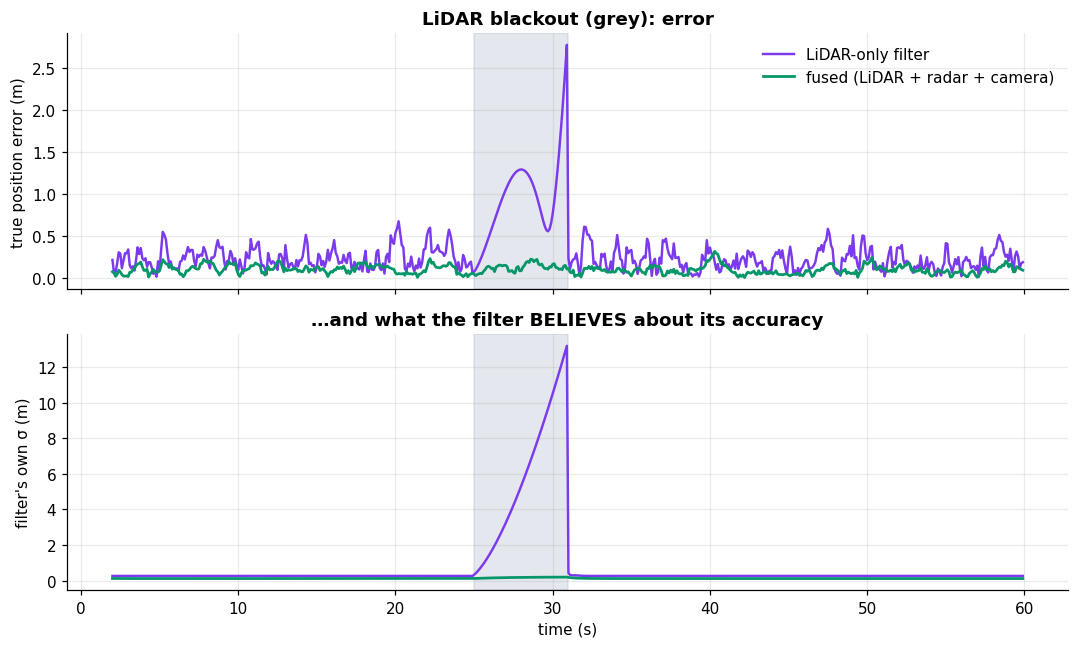

During the blackout: LiDAR-only error 1.10 m | fused error 0.13 m


In [37]:
meas_bo = make_measurements(SENSORS, blackout={"LiDAR": (25.0, 31.0)})
log_l, log_f = track(meas_bo, ["LiDAR"]), track(meas_bo)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax in (a1, a2):
    ax.axvspan(25, 31, color=GREY, alpha=.25)
a1.plot(GRID, pos_error(log_l), color=SENSORS["LiDAR"]["color"], lw=1.6, label="LiDAR-only filter")
a1.plot(GRID, pos_error(log_f), color=GREEN, lw=1.8, label="fused (LiDAR + radar + camera)")
a1.set(ylabel="true position error (m)", title="LiDAR blackout (grey): error"); a1.legend()
a2.plot(GRID, sigma_on_grid(log_l), color=SENSORS["LiDAR"]["color"], lw=1.6)
a2.plot(GRID, sigma_on_grid(log_f), color=GREEN, lw=1.8)
a2.set(xlabel="time (s)", ylabel="filter's own σ (m)", title="…and what the filter BELIEVES about its accuracy")
plt.tight_layout(); plt.show()
bo = (GRID >= 25) & (GRID < 31)
print(f"During the blackout: LiDAR-only error {rmse(pos_error(log_l)[bo]):.2f} m | fused error {rmse(pos_error(log_f)[bo]):.2f} m")

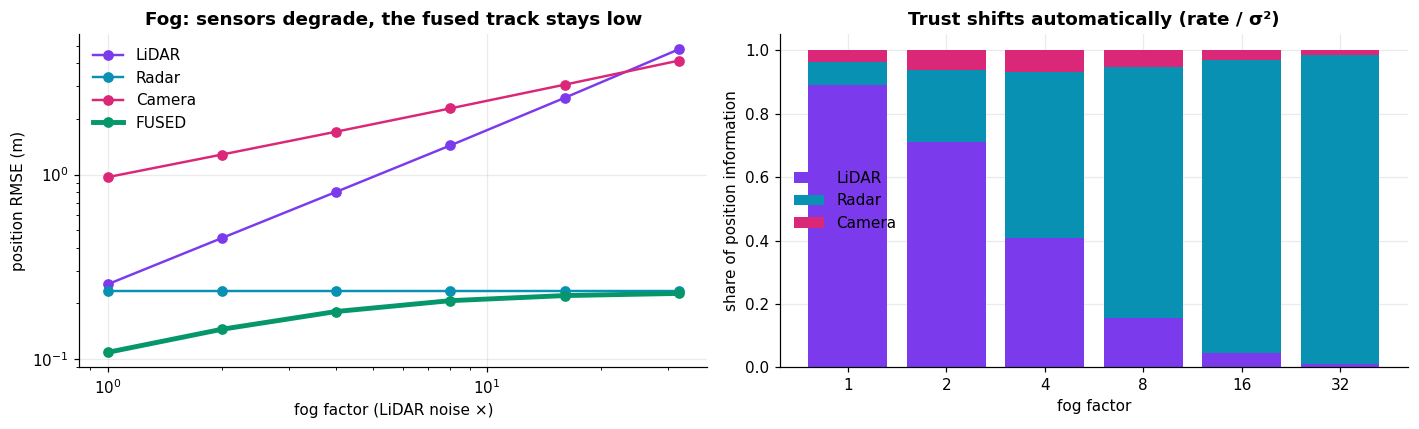

In [38]:
def fog(f):
    """Return a copy of SENSORS with LiDAR/camera noise scaled by fog.

    Args:
        f: Fog severity factor (1 = clear weather, larger = foggier).

    Returns:
        dict: A new sensors dict with `LiDAR`'s `pos_sd` scaled by `f` and
        `Camera`'s `pos_sd` scaled by `sqrt(f)`; other sensors unchanged.
    """
    s = {k: dict(v) for k, v in SENSORS.items()}
    s["LiDAR"]["pos_sd"] *= f
    s["Camera"]["pos_sd"] *= np.sqrt(f)
    return s

levels = [1, 2, 4, 8, 16, 32]
curves = {n: [] for n in list(SENSORS) + ["FUSED"]}
for f in levels:
    m_f = make_measurements(fog(f))
    for n in SENSORS:
        curves[n].append(rmse(pos_error(track(m_f, [n]))))
    curves["FUSED"].append(rmse(pos_error(track(m_f))))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
for n, v in curves.items():
    a1.plot(levels, v, "o-", color=SENSORS[n]["color"] if n in SENSORS else GREEN, lw=3.2 if n == "FUSED" else 1.6, label=n)
a1.set(xscale="log", yscale="log", xlabel="fog factor (LiDAR noise ×)", ylabel="position RMSE (m)", title="Fog: sensors degrade, the fused track stays low"); a1.legend()

# how much "information" does each sensor contribute per second?  (rate / σ²)
info = np.array([[SENSORS[n]["rate"] / fog(f)[n]["pos_sd"] ** 2 for n in SENSORS] for f in levels])
info = info / info.sum(axis=1, keepdims=True)
bottom = np.zeros(len(levels))
for j, n in enumerate(SENSORS):
    a2.bar([str(l) for l in levels], info[:, j], bottom=bottom, color=SENSORS[n]["color"], label=n); bottom += info[:, j]
a2.set(xlabel="fog factor", ylabel="share of position information", title="Trust shifts automatically (rate / σ²)"); a2.legend(loc="center left")
plt.tight_layout(); plt.show()

### Một sự thật đẹp đẽ nữa: thứ tự không quan trọng
Nếu hai phép đo đến cùng một thời điểm, việc ta `update` với cái nào trước có quan trọng không? Hãy kiểm tra điều đó.

In [39]:
def fresh():
    """Create a fresh KalmanFilter with a fixed initial state, for A/B tests.

    Returns:
        KalmanFilter: A new filter instance with state `[1, 2, 3, 4]` and
        covariance `diag([4, 4, 9, 9])`.
    """
    return KalmanFilter([1, 2, 3, 4], np.diag([4., 4., 9., 9.]))
zl, Hl, Rl = np.array([1.4, 1.7]), make_H(), np.diag([.3 ** 2] * 2)                     # a LiDAR-like reading
zr, Hr, Rr = np.array([0.5, 2.6, 3.3, 3.8]), np.eye(4), np.diag([1.5 ** 2] * 2 + [.3 ** 2] * 2)   # a radar-like reading
A, B = fresh(), fresh()
A.update(zl, Hl, Rl); A.update(zr, Hr, Rr)
B.update(zr, Hr, Rr); B.update(zl, Hl, Rl)
assert np.allclose(A.x, B.x) and np.allclose(A.P, B.P)
print("LiDAR→radar:", np.round(A.x, 4)); print("radar→LiDAR:", np.round(B.x, 4))
print("✅ identical. Independent evidence simply accumulates, in any order.")

LiDAR→radar: [1.3576 1.7402 3.297  3.802 ]
radar→LiDAR: [1.3576 1.7402 3.297  3.802 ]
✅ identical. Independent evidence simply accumulates, in any order.


> ### 💡 Nhận định (Insight)
> * **Hợp nhất (Fusion) = một bộ lọc + nhiều (z, H, R).** Thêm một cảm biến chỉ có nghĩa là viết thêm `H` và `R` của nó, không gì khác.
> * **R chính là toàn bộ hợp đồng (contract).** Một R trung thực giúp bộ lọc tin tưởng đúng mức từng cảm biến trong mọi điều kiện. Một R gian dối (ví dụ, σ của LiDAR vẫn là 0.3 m ngay cả trong sương mù dày đặc) khiến việc hợp nhất *tệ hơn* so với chỉ dùng một cảm biến.
> * Các hệ thống thực tế còn thêm một *bộ quản lý track (track manager)* (sinh/mất đối tượng) và *gán dữ liệu (data association)* (phát hiện nào thuộc về đối tượng nào), đây là các lớp cao hơn nằm trên lớp này.

---
## Phần 7 · Khi mọi thứ đi sai (10 phút · tự code bài 7.1, có chấm)
🎯 **Mục tiêu:** làm quen với hai lỗi thường gây hại cho hệ thống thực tế, outlier (giá trị ngoại lai) và độ trễ (latency), và cách khắc phục chúng.

### 7a · Outlier (giá trị ngoại lai), và cổng lọc (gate)
Đôi khi LiDAR trả về một **bóng ma (ghost)** (một phản xạ, hoặc một vật thể sai): một phép đo cách giá trị thật tới 20 m. Một bộ lọc tin tưởng mọi thứ sẽ bị kéo lệch đi. Cách chữa là dùng một **cổng lọc (gate)**: trước khi dùng một phép đo, hãy hỏi *"nó bất ngờ đến mức nào?"* bằng **khoảng cách Mahalanobis (Mahalanobis distance)**

$$d^2=\nu^\top S^{-1}\nu \qquad (\nu = z - Hx^-,\; S = HP^-H^\top+R)$$

Nếu bộ lọc trung thực, d² tuân theo **phân phối χ² (chi-bình phương)** với số bậc tự do bằng số thành phần của phép đo (2 cho x, y). Hãy loại bỏ bất kỳ giá trị nào vượt quá phân vị thứ 99 (99th percentile). Điều đó có nghĩa là ta chỉ loại nhầm 1% dữ liệu tốt.

### ✏️ Bài tập 7.1 · Cập nhật có cổng lọc (gated update) (8 phút)
Viết hàm `gated_update(kf, z, H, R, p=0.99)`. Tính ν, S và d² (dùng `np.linalg.solve(S, y)` thay vì tính nghịch đảo tường minh). Nếu d² vượt quá `chi2.ppf(p, df=len(z))`, trả về `False` mà **không** đụng vào bộ lọc. Ngược lại, gọi `kf.update(z, H, R)` và trả về `True`.


In [40]:
def gated_update(kf, z, H, R, p=0.99):
    """Apply a chi-squared gated Kalman update, rejecting outliers.

    Args:
        kf: A `KalmanFilter` instance, updated in place if the measurement
            is accepted.
        z: Measurement vector.
        H: Measurement matrix.
        R: Measurement noise covariance.
        p: Gate probability; a measurement is rejected if its squared
            Mahalanobis distance exceeds the chi-squared `p`-quantile.

    Returns:
        bool: True if the measurement was accepted and the filter updated,
        False if it was rejected as an outlier (filter left unchanged).
    """
    y = z - H @ kf.x
    S = H @ kf.P @ H.T + R
    d2 = float(y @ np.linalg.solve(S, y))
    if d2 > chi2.ppf(p, df=len(z)):
        return False
    kf.update(z, H, R)
    return True

In [41]:
def check_gate():
    """Verify `gated_update` rejects a far outlier, accepts a normal one.

    Raises:
        AssertionError: If an outlier is accepted, a rejected update still
            changes the state, or a reasonable reading is rejected.
    """
    kf = KalmanFilter([0, 0, 0, 0], np.diag([1., 1., 1., 1.]))
    H, R = make_H(), np.eye(2) * 0.25
    x_before = kf.x.copy()
    assert gated_update(kf, np.array([40., 40.]), H, R) is False, "a reading 56 m away must be rejected"
    assert np.allclose(kf.x, x_before), "a rejected measurement must NOT change the state"
    assert gated_update(kf, np.array([0.5, -0.4]), H, R) is True, "a reasonable reading must be accepted"
    print(f"✅ Exercise 7.1 passed (gate threshold for 2 numbers at 99%: d² = {chi2.ppf(.99, 2):.2f})")
check_gate()

✅ Exercise 7.1 passed (gate threshold for 2 numbers at 99%: d² = 9.21)


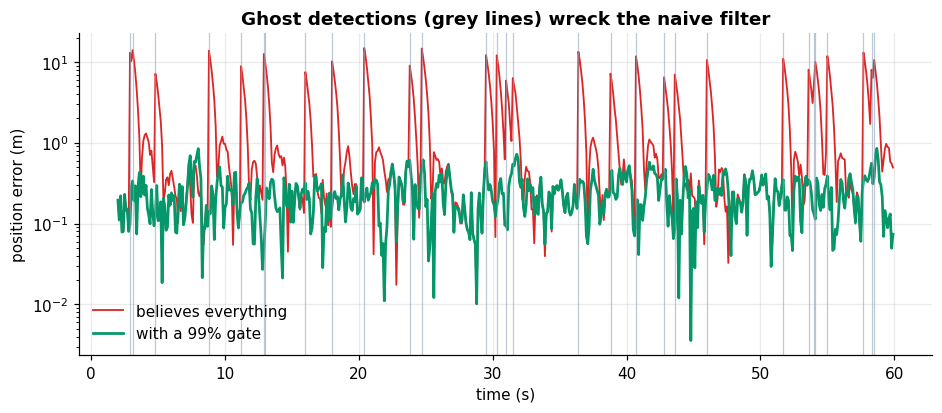

ghosts caught: 30/30   |   good readings wrongly rejected: 9/570 (1.6%)
RMSE: naive 3.46 m  vs  gated 0.28 m
✅ the gate rescued the track


In [42]:
def run_fusion_gated(meas, q, x0, P0, p=0.99):
    """Run `run_fusion`-style tracking, with outlier gating on updates.

    Args:
        meas: List of `(timestamp, name, z, H, R)` tuples, sorted by time.
        q: Process noise strength passed to `make_Q`.
        x0: Initial state estimate.
        P0: Initial state covariance.
        p: Gate probability, forwarded to `gated_update`.

    Returns:
        tuple: `(log, accepted)` where `log` is the `(timestamp, x, P)`
        list (as in `run_fusion`) and `accepted` is a boolean array marking
        which measurements passed the gate.
    """
    kf, t_prev, log, accepted = KalmanFilter(x0, P0), 0.0, [], []
    for ts, name, z, H, R in meas:
        if ts - t_prev > 0:
            kf.predict(make_F(ts - t_prev), make_Q(ts - t_prev, q))
        accepted.append(gated_update(kf, z, H, R, p))
        t_prev = max(t_prev, ts)
        log.append((ts, kf.x.copy(), kf.P.copy()))
    return log, np.array(accepted)

# LiDAR stream with 4% "ghost" detections 15-40 m away
rng7 = np.random.default_rng(5)
lidar = make_measurements({"LiDAR": SENSORS["LiDAR"]}, seed=2)
is_ghost = rng7.random(len(lidar)) < 0.04
ang, mag = rng7.uniform(0, 2 * np.pi, len(lidar)), rng7.uniform(15, 40, len(lidar))
lidar_bad = [(ts, nm, z + g * m * np.array([np.cos(a), np.sin(a)]), H, R)
             for (ts, nm, z, H, R), g, a, m in zip(lidar, is_ghost, ang, mag)]

log_naive = run_fusion(lidar_bad, Q_FUSE, X0, P0F)
log_gate, accepted = run_fusion_gated(lidar_bad, Q_FUSE, X0, P0F)

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(GRID, pos_error(log_naive), color=RED, lw=1.2, label="believes everything")
ax.plot(GRID, pos_error(log_gate), color=GREEN, lw=1.8, label="with a 99% gate")
for ts in np.array([m[0] for m in lidar_bad])[is_ghost]:
    ax.axvline(ts, color=GREY, lw=.8, alpha=.6)
ax.set(yscale="log", xlabel="time (s)", ylabel="position error (m)", title="Ghost detections (grey lines) wreck the naive filter"); ax.legend()
plt.show()
caught = (~accepted & is_ghost).sum(); false_rej = (~accepted & ~is_ghost).sum()
print(f"ghosts caught: {caught}/{is_ghost.sum()}   |   good readings wrongly rejected: {false_rej}/{(~is_ghost).sum()} ({false_rej / (~is_ghost).sum():.1%})")
print(f"RMSE: naive {rmse(pos_error(log_naive)):.2f} m  vs  gated {rmse(pos_error(log_gate)):.2f} m")
assert rmse(pos_error(log_gate)) < 0.5 * rmse(pos_error(log_naive))
print("✅ the gate rescued the track")

> ⚠️ **Cạm bẫy: cổng lọc bị khóa cứng (gate lock-out).** Nếu bộ lọc trở nên *sai lệch mà vẫn quá tự tin*, cổng lọc sẽ từ chối mọi phép đo tốt và track sẽ không bao giờ hồi phục được. Các hệ thống thực tế đếm số lần bị từ chối liên tiếp và **khởi tạo lại (re-initialise)** track sau, chẳng hạn, 5 lần liên tiếp.

### 7b · Độ trễ (Latency), kẻ giết người thầm lặng 🕰️
LiDAR quay, xử lý rồi gửi một lượt quét (scan), nên phép đo đến nơi **sau 0.1 đến 0.5 giây kể từ lúc nó được thu thập**. Điều gì xảy ra nếu ta giả vờ rằng nó mô tả chiếc xe *ngay lúc này*? Một chiếc xe chạy 8 m/s di chuyển 2.4 m trong 0.3 giây, lớn hơn nhiều so với nhiễu cảm biến 0.3 m!

Hai chiến lược: **ngây thơ (naive)** (dùng thời điểm đến nơi làm mốc thời gian) so với **đúng đắn (correct)** (dùng mốc thời gian *thu thập (capture)*, để bộ lọc dự đoán đến đúng thời điểm; đầu ra tại thời điểm *t* chỉ dùng những gì đã đến, rồi ngoại suy tiếp).

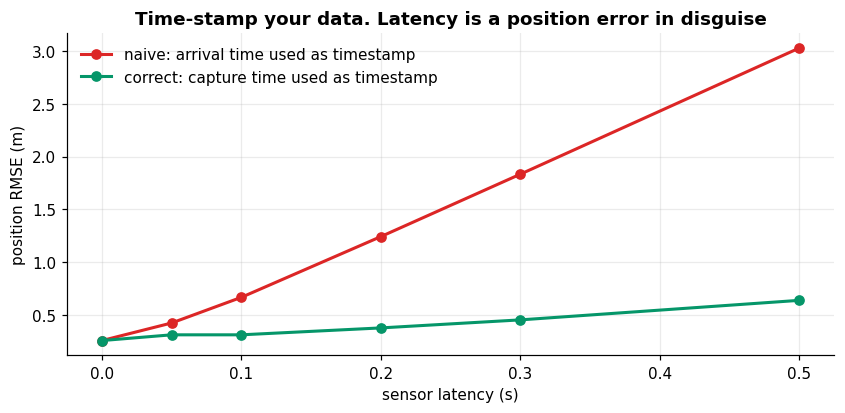

At 0.3 s latency: naive 1.83 m  vs  correct 0.45 m


In [43]:
delays = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
naive_err, correct_err = [], []
for d in delays:
    only_lidar = {"LiDAR": SENSORS["LiDAR"]}
    m_naive = make_measurements(only_lidar, stamp="arrival", latency={"LiDAR": d})     # wrong: stamped when it ARRIVED
    m_right = make_measurements(only_lidar, stamp="capture", latency={"LiDAR": d})     # right: stamped when it was CAPTURED
    naive_err.append(rmse(pos_error(track(m_naive))))
    correct_err.append(rmse(pos_error(track(m_right), delay=d)))

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(delays, naive_err, "o-", color=RED, lw=2, label="naive: arrival time used as timestamp")
ax.plot(delays, correct_err, "o-", color=GREEN, lw=2, label="correct: capture time used as timestamp")
ax.set(xlabel="sensor latency (s)", ylabel="position RMSE (m)", title="Time-stamp your data. Latency is a position error in disguise"); ax.legend()
plt.show()
print(f"At 0.3 s latency: naive {naive_err[4]:.2f} m  vs  correct {correct_err[4]:.2f} m")

> ### 💡 Nhận định (Insight): danh sách kiểm tra lỗi (debugging checklist) bạn sẽ thực sự dùng đến
> | Triệu chứng | Nguyên nhân khả dĩ | Cách khắc phục |
> |:--|:--|:--|
> | Track bị trễ khi vào cua | Q quá nhỏ | tăng Q |
> | Track rung giật như cảm biến thô | Q quá lớn hoặc R quá nhỏ | giảm Q, tăng R |
> | Một phép đo tệ làm lệch cả track | không có cổng lọc (gate) | gating χ² (7a) |
> | Lệch hằng định so với giá trị thật | **thiên lệch (bias)** của cảm biến (không phải nhiễu!) | hiệu chuẩn (calibrate), hoặc thêm bias vào trạng thái (state) |
> | Sai số tỉ lệ với tốc độ | **độ trễ (latency) / mốc thời gian (timestamp)** | gắn mốc thời gian lúc thu thập (7b) |
> | Mọi thứ ổn, rồi đột nhiên xuất hiện NaN | P mất tính đối xứng / xác định dương | cập nhật dạng Joseph (Joseph-form update), đối xứng hóa lại P |
> | NIS trung bình ≫ 1 | bộ lọc quá tự tin | tăng Q hoặc R |

---
## 🚨 Phần 9 · NHIỆM VỤ THẬT: Chẩn đoán cảm biến cho xe tự hành Lynx-07 (25 phút, **có chấm điểm, trong buổi lab**)

Bạn vừa được nhận vào đội kỹ sư cảm biến của phòng R&D xe tự hành **Dự án Lynx**. Xe thử nghiệm **Lynx-07** vừa hoàn thành một lượt chạy thử ngoài bãi test, dùng hai cảm biến định vị: **GPS-RTK** và **UWB** (định vị siêu băng rộng, giống GPS trong nhà). Đội vận hành báo lại:

> *"Một trong hai cảm biến đang có vấn đề — có thể lệch, có thể nhiễu hơn thông số kỹ thuật ghi nhận, hoặc thỉnh thoảng báo bậy. Chúng tôi không có đủ thời gian để kiểm tra lại từng cảm biến, và xe **không có GPS tham chiếu độ chính xác cao** để so sánh. Bạn dùng chính bộ lọc Kalman đã học để tìm ra vấn đề và báo cáo lại giúp chúng tôi."*

**Đây là phần khác biệt so với Phần 1–8:** dữ liệu bạn nhận được ở đây được sinh ra **riêng cho bạn** (từ `STUDENT_ID` bạn nhập), và bạn **không có ground truth (giá trị thật)** để so sánh — giống hệt tình huống thật khi vận hành một hệ thống đã triển khai. Không có một "đáp án mẫu" chung để tra cứu hay chép từ bạn bè; bạn phải tự chạy, tự đọc số liệu, và tự lập luận trên nhiệm vụ của chính mình. Dùng AI để hiểu khái niệm thì rất tốt — nhưng AI không thể đọc hộ con số của riêng bạn.

**Lưu ý liêm chính học thuật:** hàm sinh dữ liệu có cờ `_reveal_truth` chỉ dành cho giảng viên chấm bài. Tự ý bật nó lên để "xem đáp án" cũng giống như quay cóp — bạn chỉ đang tự tước đi cơ hội luyện kỹ năng chẩn đoán, kỹ năng duy nhất mà Phần 9 này thật sự kiểm tra.


In [44]:
import hashlib

def seed_from_id(student_id: str) -> int:
    """Derive a reproducible personal random seed from a student ID.

    Args:
        student_id: The student's ID or name, as a string.

    Returns:
        int: A deterministic seed derived from the SHA-256 hash of the
        (lowercased, stripped) `student_id`. The same ID always yields the
        same seed; different IDs yield different (effectively random) seeds.
    """
    h = hashlib.sha256(student_id.strip().lower().encode()).hexdigest()
    return int(h[:8], 16)

def _true_mission_path(rng, T, dt_true):
    """Generate a smooth, randomized ground-truth path for the mission.

    Args:
        rng: A `numpy.random.Generator`, already seeded.
        T: Mission duration, in seconds.
        dt_true: Time resolution of the generated path, in seconds.

    Returns:
        tuple: `(tt, true_path)` where `tt` is the time vector and
        `true_path` is an array of shape `(len(tt), 4)` with columns
        `[x, y, vx, vy]`.
    """
    n_wp = rng.integers(4, 7)
    wps = np.vstack([[0, 0], rng.uniform(-40, 40, size=(n_wp, 2))])
    seg_t = np.linspace(0, T, len(wps))
    tt = np.arange(0, T, dt_true)
    px = np.interp(tt, seg_t, wps[:, 0]); py = np.interp(tt, seg_t, wps[:, 1])
    k = np.ones(15) / 15
    px = np.convolve(px, k, mode="same"); py = np.convolve(py, k, mode="same")
    vx = np.gradient(px, dt_true); vy = np.gradient(py, dt_true)
    return tt, np.stack([px, py, vx, vy], axis=1)

def generate_mission_log(student_id, T=90.0, dt_true=0.05, _reveal_truth=False):
    """Generate one personal sensor log for the Lynx-07 test vehicle.

    Every student gets a different (but reproducible) mission: a different
    path, and a different hidden sensor fault. `_reveal_truth=True` is for
    instructor grading only -- flipping it yourself only cheats you out of
    the actual exercise (diagnosing a fault you can't see is the point).

    Args:
        student_id: The student's ID or name; determines the random seed
            for this mission (see `seed_from_id`).
        T: Mission duration, in seconds.
        dt_true: Time resolution of the internally simulated ground truth.
        _reveal_truth: If True, also return the hidden ground truth and
            fault parameters. Instructor use only.

    Returns:
        dict: If `_reveal_truth` is False (the default), the `public` dict
        with sensor specs and measurements (`SPEC`, `t_gps`, `z_gps`,
        `t_uwb`, `z_uwb`, `T`).
        tuple: If `_reveal_truth` is True, `(public, truth)` where `truth`
        additionally contains the true path and the injected fault
        parameters (`fault_sensor`, `fault_type`, `bias_vec`, `noise_mult`,
        `burst_start`, `burst_len`).
    """
    seed = seed_from_id(student_id)
    rng = np.random.default_rng(seed)
    tt, true_path = _true_mission_path(rng, T, dt_true)

    SPEC = {"GPS": dict(rate=5.0, pos_sd=0.5), "UWB": dict(rate=10.0, pos_sd=1.0)}
    fault_sensor = rng.choice(["GPS", "UWB"])
    fault_type = rng.choice(["bias", "underrated_noise", "outlier_burst"])
    bias_vec = rng.normal(0, 1.0, 2) * rng.choice([-1, 1], 2) * 2.5 if fault_type == "bias" else np.zeros(2)
    noise_mult = rng.uniform(2.5, 4.5) if fault_type == "underrated_noise" else 1.0
    burst_start = rng.uniform(25, T - 20); burst_len = rng.uniform(4, 9); burst_mag = rng.uniform(8, 20)

    def make_sensor(name):
        """Simulate one sensor's noisy measurement stream for this mission.

        Args:
            name: Sensor name, `"GPS"` or `"UWB"`.

        Returns:
            tuple: `(tc, z)`, the capture times and noisy position
            measurements for this sensor, including any injected fault.
        """
        rate, sd = SPEC[name]["rate"], SPEC[name]["pos_sd"]
        tc = np.arange(0, T, 1.0 / rate)
        idx = np.clip((tc / dt_true).astype(int), 0, len(tt) - 1)
        true_xy = true_path[idx, :2]
        eff_sd = sd * (noise_mult if fault_sensor == name and fault_type == "underrated_noise" else 1.0)
        z = true_xy + rng.normal(0, eff_sd, true_xy.shape)
        if fault_sensor == name and fault_type == "bias":
            z = z + bias_vec
        if fault_sensor == name and fault_type == "outlier_burst":
            in_burst = (tc >= burst_start) & (tc < burst_start + burst_len)
            ang = rng.uniform(0, 2 * np.pi, int(in_burst.sum()))
            z[in_burst] += burst_mag * np.stack([np.cos(ang), np.sin(ang)], axis=1)
        return tc, z

    t_gps, z_gps = make_sensor("GPS")
    t_uwb, z_uwb = make_sensor("UWB")
    public = dict(SPEC=SPEC, t_gps=t_gps, z_gps=z_gps, t_uwb=t_uwb, z_uwb=z_uwb, T=T)
    if not _reveal_truth:
        return public
    truth = dict(path=true_path, t=tt, fault_sensor=fault_sensor, fault_type=fault_type,
                 bias_vec=bias_vec, noise_mult=noise_mult, burst_start=burst_start, burst_len=burst_len)
    return public, truth

print("Hạ tầng Phần 9 đã sẵn sàng: seed_from_id(), generate_mission_log()")

Hạ tầng Phần 9 đã sẵn sàng: seed_from_id(), generate_mission_log()


In [45]:
STUDENT_ID = "2A202602687"
mission = generate_mission_log(STUDENT_ID)
print(f"Nhiệm vụ đã tạo cho '{STUDENT_ID}' (seed={seed_from_id(STUDENT_ID)})")
print(f"GPS: {len(mission['t_gps'])} điểm đo, UWB: {len(mission['t_uwb'])} điểm đo, thời lượng {mission['T']:.0f}s")

Nhiệm vụ đã tạo cho '2A202602687' (seed=2598272290)
GPS: 450 điểm đo, UWB: 900 điểm đo, thời lượng 90s


### 🗺️ Bản đồ nhiệm vụ thô
Chạy cell dưới để xem dữ liệu thô của **chính bạn**. Mỗi lần bạn đổi `STUDENT_ID`, nhiệm vụ sẽ khác đi hoàn toàn (quỹ đạo khác, cảm biến lỗi khác, loại lỗi khác).

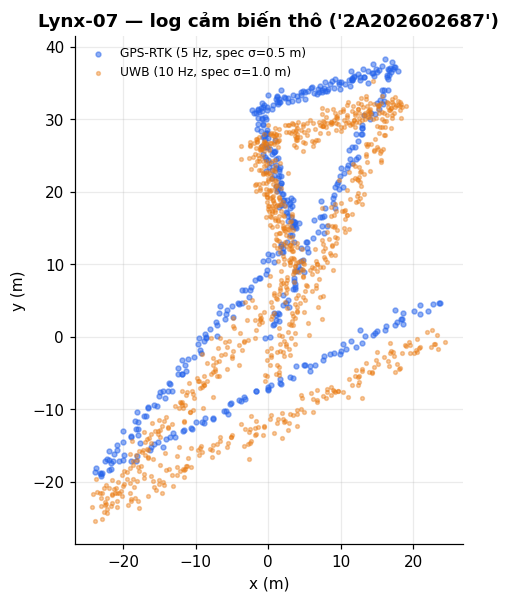

Đội vận hành báo: 'một trong hai cảm biến này đang có vấn đề, nhưng chúng tôi không chắc là cái nào.'


In [46]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(*mission["z_gps"].T, s=10, color=BLUE, alpha=.5,
           label=f"GPS-RTK ({mission['SPEC']['GPS']['rate']:.0f} Hz, spec σ={mission['SPEC']['GPS']['pos_sd']} m)")
ax.scatter(*mission["z_uwb"].T, s=6, color=ORANGE, alpha=.4,
           label=f"UWB ({mission['SPEC']['UWB']['rate']:.0f} Hz, spec σ={mission['SPEC']['UWB']['pos_sd']} m)")
ax.set(aspect="equal", xlabel="x (m)", ylabel="y (m)", title=f"Lynx-07 — log cảm biến thô (\'{STUDENT_ID}\')")
ax.legend(fontsize=8); plt.show()
print("Đội vận hành báo: 'một trong hai cảm biến này đang có vấn đề, nhưng chúng tôi không chắc là cái nào.'")

### ✏️ Bài tập 9.1 · Đọc chẩn đoán cảm biến (khoảng 8 phút, có chấm)
🎯 **Mục tiêu:** xác định cảm biến nào đang có vấn đề, và đó là loại vấn đề gì.

Có ba kiểu lỗi, mỗi kiểu một dấu vân tay trong NIS (bài 4.1; kỳ vọng của NIS **2 chiều** là khoảng **2**) và trong phần dư `y = z − Hx`:

| Loại lỗi | `FIX_METHOD` | Dấu hiệu |
|:--|:--|:--|
| **Lệch hằng số (bias)** | `bias` | Residual trung bình lệch khỏi `[0, 0]` theo một hướng cố định |
| **Nhiễu bị đánh giá thấp (underrated noise)** | `inflate_R` | NIS **trung bình** và **trung vị** đều cao hơn hẳn khoảng 2 |
| **Nhiễu đột biến (outlier burst)** | `gate` | NIS **trung bình** rất cao, nhưng NIS **trung vị** vẫn gần mức bình thường |

Hàm `diagnose(mission)` đã điền sẵn. Chạy và đọc số của **chính bạn**, rồi điền bốn biến ở ô code ngay bên dưới. Không chép số của người khác: `STUDENT_ID` khác thì log khác.


In [47]:
def diagnose(mission, q=0.3):
    """Run a provisional filter that trusts SPEC, and log diagnostics.

    Args:
        mission: A mission dict as returned by `generate_mission_log`.
        q: Process noise strength assumed for the provisional filter.

    Returns:
        dict: Keyed by sensor name (`"GPS"`, `"UWB"`), each value a dict
        with `nis` (array of per-measurement NIS values) and `resid_mean`
        (the mean 2-D residual vector), for you to inspect for signs of a
        sensor fault.
    """
    H = make_H()
    meas = sorted([(t, "GPS", z) for t, z in zip(mission["t_gps"], mission["z_gps"])] +
                  [(t, "UWB", z) for t, z in zip(mission["t_uwb"], mission["z_uwb"])], key=lambda r: r[0])
    kf = KalmanFilter([0, 0, 0, 0], np.diag([50., 50., 20., 20.]))
    t_prev = 0.0
    log = {"GPS": {"nis": [], "resid": []}, "UWB": {"nis": [], "resid": []}}
    for t, name, z in meas:
        dt = t - t_prev
        if dt > 0:
            kf.predict(make_F(dt), make_Q(dt, q))
        R = np.eye(2) * mission["SPEC"][name]["pos_sd"] ** 2
        y, S, K = kf.update(z, H, R)
        nis = float(y @ np.linalg.solve(S, y))
        log[name]["nis"].append(nis)
        log[name]["resid"].append(y)
        t_prev = t
    out = {}
    for name in ["GPS", "UWB"]:
        nis = np.array(log[name]["nis"]); resid = np.array(log[name]["resid"])
        out[name] = dict(nis=nis, resid_mean=resid.mean(axis=0))
    return out

diag = diagnose(mission)
for name in ["GPS", "UWB"]:
    d = diag[name]
    print(f"{name}: n={len(d['nis'])}  mean(NIS)={d['nis'].mean():.2f}  "
          f"median(NIS)={np.median(d['nis']):.2f}  mean residual={np.round(d['resid_mean'], 2)}")


GPS: n=450  mean(NIS)=11.50  median(NIS)=10.23  mean residual=[-0.05  1.82]
UWB: n=900  mean(NIS)=14.04  median(NIS)=13.01  mean residual=[ 0.08 -3.59]


In [48]:
def check_diagnose():
    """Sanity-check that `diagnose` produced well-formed output.

    This only checks structural validity (correct keys, matching lengths,
    no NaN/Inf) -- it cannot check whether your diagnosis is correct, since
    that is graded separately against data you don't have access to.

    Raises:
        AssertionError: If the output of `diagnose` is malformed.
    """
    assert set(diag.keys()) == {"GPS", "UWB"}
    for name in ["GPS", "UWB"]:
        key = f"t_{name.lower()}"
        assert len(diag[name]["nis"]) == len(mission[key]), f"{name}: sai số lượng NIS"
        assert np.all(np.isfinite(diag[name]["nis"])), f"{name}: có NIS không hợp lệ (NaN/inf)"
        assert diag[name]["resid_mean"].shape == (2,)
    print("✅ Bài tập 9.1 chạy hợp lệ — các mảng NIS đầy đủ, không có NaN/inf. **Không có đáp án tự động cho việc chẩn đoán**: đó chính là kỹ năng bài tập này luyện cho bạn. Hãy đọc các con số được in ở trên.")
check_diagnose()

✅ Bài tập 9.1 chạy hợp lệ — các mảng NIS đầy đủ, không có NaN/inf. **Không có đáp án tự động cho việc chẩn đoán**: đó chính là kỹ năng bài tập này luyện cho bạn. Hãy đọc các con số được in ở trên.


Điền bốn biến ở ô code kế tiếp. Phần viết tay được chấm nằm ở ô báo cáo cuối Phần 9, không điền ở đây.


In [49]:
# Bốn biến này được chấm tự động. Sửa cho khớp số bạn vừa đọc.
MY_DIAGNOSIS_SENSOR = "UWB"   # "GPS" hoặc "UWB"
MY_DIAGNOSIS_TYPE   = "bias"   # "bias", "underrated_noise", hoặc "outlier_burst"
FIX_SENSOR = "UWB"            # cảm biến bạn sửa: "GPS" hoặc "UWB"
FIX_METHOD = "bias"            # "bias", "inflate_R", hoặc "gate"


In [50]:
def check_diagnosis_vars():
    """Sanity-check the four graded labels before the filter runs.

    Raises:
        AssertionError: If a label is not one of the allowed values.
    """
    assert MY_DIAGNOSIS_SENSOR in {"GPS", "UWB"}, "MY_DIAGNOSIS_SENSOR phải là 'GPS' hoặc 'UWB'"
    assert MY_DIAGNOSIS_TYPE in {"bias", "underrated_noise", "outlier_burst"}, (
        "MY_DIAGNOSIS_TYPE phải là 'bias', 'underrated_noise', hoặc 'outlier_burst'")
    assert FIX_SENSOR in {"GPS", "UWB"}, "FIX_SENSOR phải là 'GPS' hoặc 'UWB'"
    assert FIX_METHOD in {"bias", "inflate_R", "gate"}, (
        "FIX_METHOD phải là 'bias', 'inflate_R', hoặc 'gate'")
    print(f"✅ Đã ghi nhận chẩn đoán: {MY_DIAGNOSIS_SENSOR} / {MY_DIAGNOSIS_TYPE}.")
    print(f"✅ FIX_SENSOR={FIX_SENSOR} FIX_METHOD={FIX_METHOD}")
check_diagnosis_vars()


✅ Đã ghi nhận chẩn đoán: UWB / bias.
✅ FIX_SENSOR=UWB FIX_METHOD=bias


### ✏️ Bài tập 9.2 · Chọn một cách sửa (khoảng 8 phút, có chấm)
`run_mission_filter` đã điền sẵn. Bạn không viết lại vòng lặp Kalman. Hai biến `FIX_SENSOR` và `FIX_METHOD` ở ô trên quyết định cách sửa:

- `bias`: trừ residual trung bình của đúng cảm biến đó khỏi phép đo.
- `inflate_R`: nhân R của cảm biến đó theo NIS đang thấy (NIS 2 chiều khỏe mạnh có trung bình khoảng 2).
- `gate`: gọi `gated_update` (bài 7.1, hàm trả về đúng hoặc sai) chỉ cho cảm biến đó.

Ô kiểm tra yêu cầu pooled mean NIS < 8. Nhiễu đánh giá thấp và outlier thường giữ NIS rất cao nếu sửa sai. Với lệch hằng số, hãy tin residual hơn là NIS.


In [51]:
def apply_mission_fix(diag, fix_sensor, fix_method):
    """Turn a diagnosis label into filter kwargs. Students do not tune numbers by hand.

    Args:
        diag: Output of `diagnose`.
        fix_sensor: `"GPS"` or `"UWB"`.
        fix_method: `"bias"`, `"inflate_R"`, or `"gate"`.

    Returns:
        dict: Keyword arguments for `run_mission_filter`.
    """
    kwargs = dict(gps_bias_corr=np.zeros(2), uwb_bias_corr=np.zeros(2),
                  gps_r_mult=1.0, uwb_r_mult=1.0, use_gate=False, gate_sensor=None)
    if fix_method == "bias":
        key = "gps_bias_corr" if fix_sensor == "GPS" else "uwb_bias_corr"
        kwargs[key] = np.asarray(diag[fix_sensor]["resid_mean"], dtype=float)
    elif fix_method == "inflate_R":
        # 2-D NIS has expectation ~2 when R is honest. Scale that sensor's R up to match.
        key = "gps_r_mult" if fix_sensor == "GPS" else "uwb_r_mult"
        kwargs[key] = max(2.0, float(np.mean(diag[fix_sensor]["nis"])) / 2.0)
    elif fix_method == "gate":
        kwargs["use_gate"] = True
        kwargs["gate_sensor"] = fix_sensor
    else:
        raise ValueError("FIX_METHOD không hợp lệ")
    return kwargs

def run_mission_filter(mission, q=0.3,
                       gps_bias_corr=np.zeros(2), uwb_bias_corr=np.zeros(2),
                       gps_r_mult=1.0, uwb_r_mult=1.0,
                       use_gate=False, gate_sensor=None, gate_p=0.999):
    """Fuse GPS and UWB for the whole mission, with one optional fault correction.

    Args:
        mission: A mission dict as returned by `generate_mission_log`.
        q: Process noise strength passed to `make_Q`.
        gps_bias_corr: Bias subtracted from GPS readings before the update.
        uwb_bias_corr: Bias subtracted from UWB readings before the update.
        gps_r_mult: Multiplier on GPS measurement variance.
        uwb_r_mult: Multiplier on UWB measurement variance.
        use_gate: If True, chi-squared gate measurements (see `gate_sensor`).
        gate_sensor: If set, only this sensor is gated. Other sensors always update.
        gate_p: Gate probability forwarded to `gated_update`.

    Returns:
        tuple: `(log, nis_all)` of accepted updates. `gated_update` returns a bool;
        NIS is computed here and is not unpacked from `gated_update`.
    """
    H = make_H()
    meas = sorted([(t, "GPS", z) for t, z in zip(mission["t_gps"], mission["z_gps"])] +
                  [(t, "UWB", z) for t, z in zip(mission["t_uwb"], mission["z_uwb"])], key=lambda r: r[0])
    kf = KalmanFilter([0, 0, 0, 0], np.diag([50., 50., 20., 20.]))
    t_prev, log, nis_all = 0.0, [], []
    bias = {"GPS": np.asarray(gps_bias_corr, dtype=float), "UWB": np.asarray(uwb_bias_corr, dtype=float)}
    r_mult = {"GPS": gps_r_mult, "UWB": uwb_r_mult}
    for t, name, z in meas:
        dt = t - t_prev
        if dt > 0:
            kf.predict(make_F(dt), make_Q(dt, q))
        zc = np.asarray(z, dtype=float) - bias[name]
        R = np.eye(2) * mission["SPEC"][name]["pos_sd"] ** 2 * r_mult[name]
        gate_this = use_gate and (gate_sensor is None or name == gate_sensor)
        if gate_this:
            y = zc - H @ kf.x
            S = H @ kf.P @ H.T + R
            nis = float(y @ np.linalg.solve(S, y))
            ok = gated_update(kf, zc, H, R, p=gate_p)
            if not ok:
                t_prev = t
                continue
        else:
            y, S, K = kf.update(zc, H, R)
            nis = float(y @ np.linalg.solve(S, y))
        log.append((t, kf.x.copy(), kf.P.copy()))
        nis_all.append(nis)
        t_prev = t
    return log, np.array(nis_all)

kw = apply_mission_fix(diag, FIX_SENSOR, FIX_METHOD)
log, nis_all = run_mission_filter(mission, **kw)
print(f"Pooled mean NIS = {nis_all.mean():.2f}  (median = {np.median(nis_all):.2f})  "
      f"trên {len(nis_all)} phép đo được chấp nhận")


Pooled mean NIS = 2.98  (median = 1.94)  trên 1350 phép đo được chấp nhận


In [52]:
def check_mission_filter():
    """Sanity-check that the final mission filter is reasonably consistent.

    Raises:
        AssertionError: If the filter produced no output, or if its pooled
            mean NIS is implausibly high (a strong sign the diagnosed fault
            was not actually corrected).
    """
    assert len(log) > 0 and len(nis_all) > 0
    assert nis_all.mean() < 8.0, (
        f"Pooled mean NIS = {nis_all.mean():.1f} vẫn còn rất cao. "
        "Rất có thể bạn chưa sửa đúng cảm biến/lỗi đã chẩn đoán ở 9.1 -- thử xem lại."
    )
    print(f"✅ Bộ lọc chạy hợp lệ, pooled mean NIS = {nis_all.mean():.2f} "
          "(ngưỡng 8. Lệch hằng số đôi khi không kéo NIS lên cao, residual mới là dấu hiệu của bias).")
check_mission_filter()

✅ Bộ lọc chạy hợp lệ, pooled mean NIS = 2.98 (ngưỡng 8. Lệch hằng số đôi khi không kéo NIS lên cao, residual mới là dấu hiệu của bias).


### 🖥️ Bảng điều khiển nhiệm vụ (Mission dashboard)
Chạy cell dưới để xem toàn cảnh: bản đồ quỹ đạo với elip độ bất định, NIS theo thời gian, và độ bất định vị trí theo thời gian — y hệt những gì một kỹ sư vận hành thật sẽ nhìn vào để đánh giá bộ lọc của bạn.

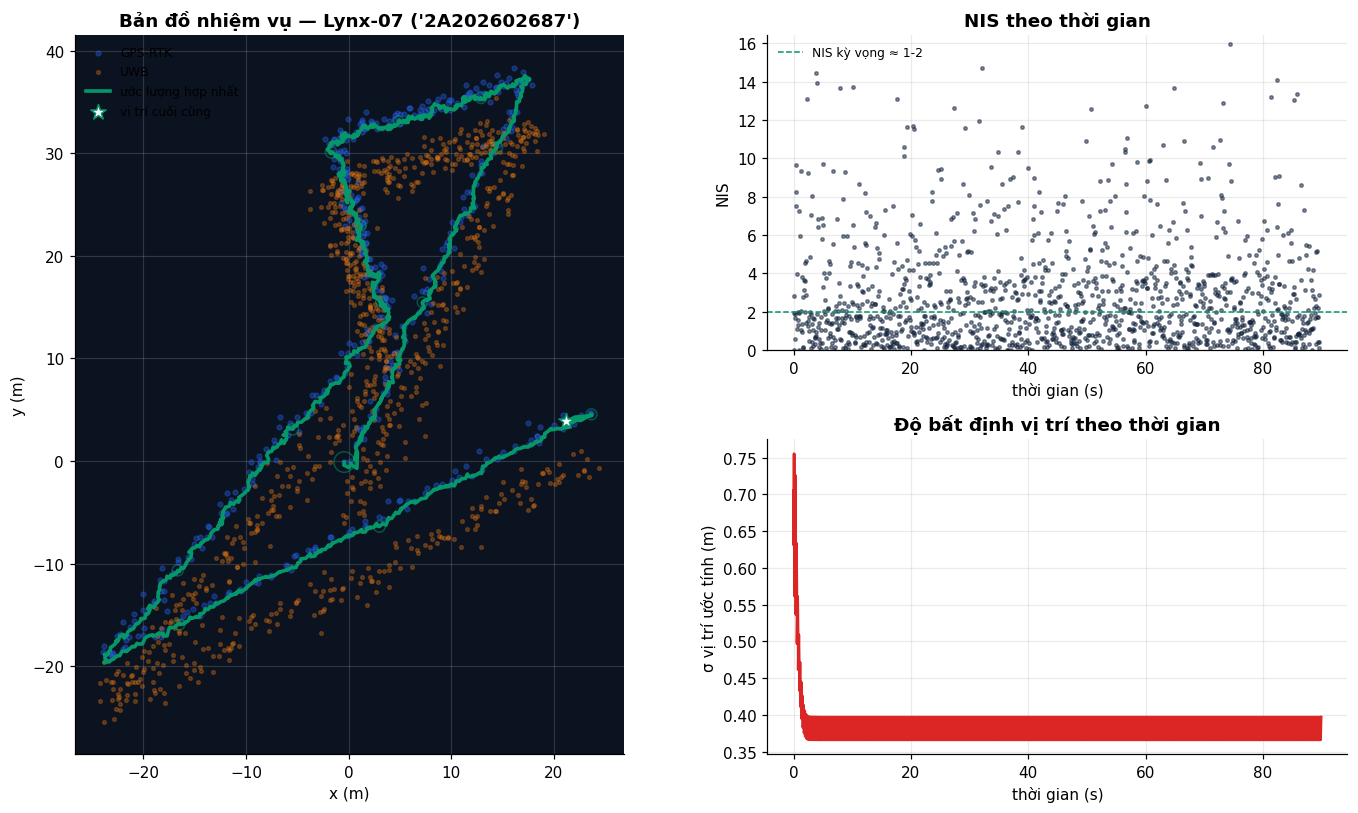

Pxx=0.078828 m², Pyy=0.078828 m²
1σ vị trí (sqrt(Pxx + Pyy)) = 0.397 m
Bán kính bao vùng tin cậy Gaussian 95% = 0.687 m


In [53]:
def plot_mission_dashboard(mission, log, nis_all, student_id):
    """Render the mission dashboard: map, NIS, and uncertainty over time.

    Args:
        mission: A mission dict as returned by `generate_mission_log`.
        log: Filter log, as returned by `run_mission_filter`.
        nis_all: Array of per-update NIS values, as returned by
            `run_mission_filter`.
        student_id: Student ID/name, used in the plot title.

    Returns:
        None: Displays a three-panel Matplotlib figure.
    """
    ts = np.array([l[0] for l in log]); xs = np.array([l[1] for l in log]); Ps = [l[2] for l in log]
    fig = plt.figure(figsize=(13, 7.5))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.3, 1])
    ax1 = fig.add_subplot(gs[:, 0]); ax2 = fig.add_subplot(gs[0, 1]); ax3 = fig.add_subplot(gs[1, 1])

    ax1.set_facecolor("#0B1220")
    ax1.scatter(*mission["z_gps"].T, s=10, color=BLUE, alpha=.35, label="GPS-RTK")
    ax1.scatter(*mission["z_uwb"].T, s=6, color=ORANGE, alpha=.3, label="UWB")
    ax1.plot(xs[:, 0], xs[:, 1], color=GREEN, lw=2.4, label="ước lượng hợp nhất")
    for i in range(0, len(xs), max(1, len(xs) // 12)):
        cov_ellipse(ax1, xs[i, :2], Ps[i][:2, :2], n_std=2.0, edgecolor=GREEN, facecolor="none", lw=1, alpha=.5)
    ax1.scatter(*xs[-1, :2], color="#fff", edgecolor=GREEN, s=110, zorder=5, marker="*", label="vị trí cuối cùng")
    ax1.set(aspect="equal", xlabel="x (m)", ylabel="y (m)", title=f"Bản đồ nhiệm vụ — Lynx-07 ('{student_id}')")
    ax1.legend(fontsize=8, loc="upper left"); ax1.grid(alpha=.15, color="#fff")

    ax2.scatter(ts, nis_all, s=5, color=INK, alpha=.5)
    ax2.axhline(2, color=GREEN, ls="--", lw=1, label="NIS kỳ vọng ≈ 1-2")
    ax2.set(xlabel="thời gian (s)", ylabel="NIS", title="NIS theo thời gian",
            ylim=(0, min(50, np.percentile(nis_all, 99) * 1.2)))
    ax2.legend(fontsize=8)

    trace = np.array([np.trace(P[:2, :2]) for P in Ps])
    ax3.plot(ts, np.sqrt(trace), color=RED, lw=1.8)
    ax3.set(xlabel="thời gian (s)", ylabel="σ vị trí ước tính (m)", title="Độ bất định vị trí theo thời gian")
    plt.tight_layout(); plt.show()

plot_mission_dashboard(mission, log, nis_all, STUDENT_ID)

P_final = log[-1][2][:2, :2]
sigma_position = np.sqrt(np.trace(P_final))
radius_95 = np.sqrt(chi2.ppf(0.95, df=2) * np.linalg.eigvalsh(P_final).max())
print(f"Pxx={P_final[0, 0]:.6f} m², Pyy={P_final[1, 1]:.6f} m²")
print(f"1σ vị trí (sqrt(Pxx + Pyy)) = {sigma_position:.3f} m")
print(f"Bán kính bao vùng tin cậy Gaussian 95% = {radius_95:.3f} m")


### ✏️ Báo cáo nhiệm vụ (khoảng 8 phút, 20 điểm chấm tay)

**✍️ Báo cáo Lynx-07**

**Kỹ sư:** `STUDENT_ID = 2A202602687`

**1. Bằng chứng**

| Cảm biến | Số phép đo | Mean NIS | Median NIS | Residual trung bình (m) |
|:--|--:|--:|--:|:--|
| GPS | 450 | 11,50 | 10,23 | [-0,05; 1,82] |
| UWB | 900 | 14,04 | 13,01 | [0,08; -3,59] |

NIS của cả hai cảm biến đều cao hơn kỳ vọng 2 cho phép đo hai chiều. Residual trung bình theo trục y của UWB lệch -3,59 m, có độ lớn gần gấp đôi GPS và ngược hướng với GPS. Đây là bằng chứng cho sự lệch có hệ thống giữa hai nguồn đo. Với giả thiết của nhiệm vụ rằng chỉ một cảm biến lỗi, tôi chẩn đoán **UWB bị bias**. Bộ lọc hợp nhất bị kéo lệch bởi UWB cũng có thể làm NIS của GPS tăng; vì vậy không thể kết luận cả hai cảm biến lỗi chỉ từ NIS cao.

**2. Cách sửa**

Chọn `FIX_SENSOR = "UWB"`, `FIX_METHOD = "bias"`. Theo hàm có sẵn, trừ vector residual trung bình khoảng [0,07891; -3,59117] m khỏi từng phép đo UWB trước khi cập nhật. Sau sửa, pooled mean NIS là **2,98**, median NIS là **1,94**, trên **1.350 phép đo được chấp nhận**, đạt yêu cầu mean NIS < 8.

`inflate_R` giảm mức tin tưởng vào cảm biến nhưng không loại bỏ độ lệch trung bình theo một hướng cố định. `gate` phù hợp với các điểm ngoại lai đột biến; ở đây mean và median NIS đều cao, kèm residual trung bình lệch rõ, nên loại bỏ vài điểm không giải quyết được bias. Kết quả sau sửa tiến gần kỳ vọng NIS 2, nhưng chưa chứng minh sai số vị trí thật đã hết.

**3. Độ tin cậy cuối**

Ở cập nhật cuối, Pxx = Pyy ≈ **0,078828 m²**. Theo chỉ số đề bài, 1σ vị trí = sqrt(Pxx + Pyy) ≈ **0,397 m**. Hiệp phương sai vị trí cuối đẳng hướng, nên với giả thiết sai số Gaussian hai chiều và không còn bias, bán kính vùng tin cậy 95% = sqrt(χ²(0,95; 2) × Pxx) ≈ **0,687 m**. Đây là độ bất định mà mô hình ước lượng, không phải sai số đã được xác nhận bằng ground truth.

**4. Hạn chế**

Nếu bias UWB thay đổi theo thời gian hoặc theo vị trí xe, trừ một vector hằng từ toàn bộ nhiệm vụ sẽ không theo kịp độ lệch mới. Ngoài ra, residual được lấy từ bộ lọc đang tin cả hai cảm biến nên có thể chỉ phản ánh một phần bias thật; P không tính thêm độ bất định của vector hiệu chỉnh. Do đó vùng tin cậy 95% có thể quá lạc quan nếu bias còn sót lại. Cần dữ liệu tham chiếu hoặc một mô hình ước lượng bias theo thời gian để kiểm chứng và xử lý tình huống này.


---
## 🏁 Tổng kết (nằm trong 8 phút đệm)

### Toàn bộ bài lab trong một trang
| Ý tưởng | Tóm tắt một dòng |
|:--|:--|
| **Niềm tin (Belief)** | Một phân phối Gaussian: trung bình (mean) = dự đoán tốt nhất, phương sai (variance) = mức nghi ngờ |
| **Hợp nhất (Fusion)** | Nhân các niềm tin → **các độ chính xác (precision) cộng dồn**; nguồn sắc nét hơn thắng |
| **Dự đoán (Predict)** | Đẩy niềm tin qua mô hình chuyển động; mức nghi ngờ tăng lên (+Q) |
| **Cập nhật (Update)** | Hợp nhất thêm một phép đo; mức nghi ngờ giảm xuống; K là núm xoay độ tin cậy |
| **Q và R** | Những phát biểu trung thực về mức nghi ngờ; tinh chỉnh sao cho NIS ≈ 1 |
| **Trạng thái ẩn (Hidden state)** | Tương quan (correlation) cho phép bạn ước lượng thứ bạn không bao giờ đo (vận tốc) |
| **Đa cảm biến (Multi-sensor)** | Cùng một bộ lọc, mỗi phép đo mang theo (z, H, R) riêng, theo thứ tự thời gian |
| **Độ bền vững (Robustness)** | Dùng cổng lọc (gate) cho outlier (χ²), gắn mốc thời gian lúc thu thập, theo dõi các đổi mới (innovation) |
| **Phi tuyến (Nonlinear)** | EKF: tuyến tính hóa bằng Jacobian; UKF/bộ lọc hạt (particle filter) khi điều đó chưa đủ |

### 🧠 Câu hỏi suy ngẫm (thảo luận với người bên cạnh)
1. Tại sao một cảm biến *tệ* vẫn có thể hữu ích, và khi nào nó lại gây hại?
2. Bộ lọc của chúng ta dùng cùng một Q cho cả quá trình chạy. Điều gì xảy ra khi phanh gấp đột ngột, và bạn sẽ xử lý việc đó như thế nào? *(gợi ý: tìm hiểu về "IMM" hoặc Q thích nghi - adaptive Q)*
3. Bạn sẽ đặt vận tốc **Doppler** của radar vào đâu trong H? Tại sao nó lại hữu ích đến vậy khi LiDAR bị mù?
4. Nếu hai cảm biến cùng chia sẻ một sai số *chung* (ví dụ: cùng dùng một bản đồ sai), tại sao việc hợp nhất chúng như hai nguồn độc lập lại phá vỡ quy tắc "các độ chính xác cộng dồn"?
5. Bạn sẽ ghi log những gì trong một hệ thống đã triển khai (deployed) để biết *khi nào* bộ lọc không còn nhất quán (consistent) nữa?


### Bước tiếp theo
* **Đọc thêm:** Roger Labbe, *Kalman and Bayesian Filters in Python* (miễn phí, dạng notebook). Bar-Shalom et al., *Estimation with Applications to Tracking and Navigation*.
* **Code tham khảo:** `filterpy`, `scipy.signal`, và `robot_localization` (ROS 2) cho các bộ lọc chất lượng sản xuất (production-grade).
* **Mở rộng bài lab này:** một bộ làm mượt (smoother) Rauch-Tung-Striebel (dùng tương lai để cải thiện quá khứ); một bộ lọc **IMM**; một **UKF**; dữ liệu thật từ *KITTI* hoặc *nuScenes* (LiDAR + radar + camera có ground truth).

*Làm tốt lắm! Bạn đã xây dựng một Kalman filter, một bộ theo dõi đa cảm biến (multi-sensor tracker), và một cổng lọc bền vững (robust gate), chỉ dùng NumPy.* 🎉

---
## Sau giờ · không tính vào 120 phút, không nằm trong 100 điểm

Phần bắt buộc kết thúc ở báo cáo phía trên. EKF, cửa sổ 0–20 giây, câu hỏi mất tín hiệu và thử thách chỉ làm nếu còn thời gian. Thưởng tối đa **+5**, ghi riêng, không cộng vào 80 điểm tự động.


---
## 🌟 Phần 8 · Bonus: Bộ lọc Kalman mở rộng (Extended Kalman Filter - EKF) (sau giờ, thưởng, không tính vào 120 phút)
🎯 **Mục tiêu:** xử lý một cảm biến **không tuyến tính (not linear)**, chẳng hạn một radar báo cáo **khoảng cách (range) và góc phương vị (bearing)** thay vì x và y.

Một radar ở vị trí *s* đo $r=\|p-s\|$ và $\varphi=\operatorname{atan2}(p_y-s_y,\;p_x-s_x)$. Đó *không* có dạng z = H·x. Thủ thuật của EKF: **tuyến tính hóa (linearise)** xung quanh ước lượng hiện tại. Thay H bằng **Jacobian** (ma trận các đạo hàm riêng) của h(x), tính tại trạng thái dự đoán. Mọi thứ khác giữ nguyên.

Trước tiên, tại sao đây lại là "gần đúng (approximate)"? Một sai số về góc phương vị khiến điểm dao động dọc theo một **cung tròn (arc)**, nên đám mây các vị trí khả dĩ có hình quả chuối, chứ không phải hình elip. (Ở đây dùng nhiễu góc phương vị phóng đại 10° để bạn thấy rõ điều này.)


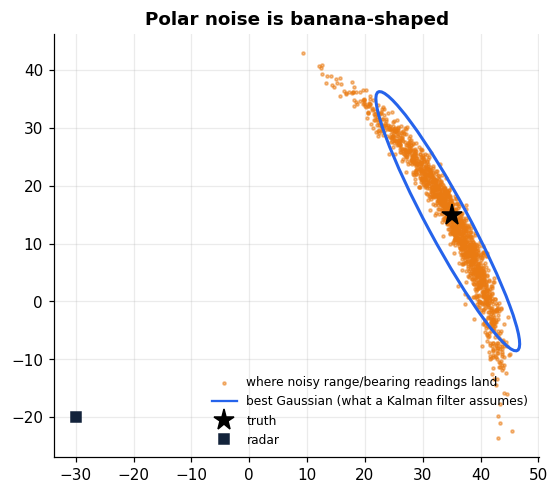

In [54]:
RADAR_POS = np.array([-30.0, -20.0])
p_true = np.array([35.0, 15.0])
rs = np.random.default_rng(0)
r0, b0 = np.hypot(*(p_true - RADAR_POS)), np.arctan2(*(p_true - RADAR_POS)[::-1])
rr, bb = r0 + rs.normal(0, 1.0, 1500), b0 + rs.normal(0, np.radians(10), 1500)
pts = RADAR_POS + np.stack([rr * np.cos(bb), rr * np.sin(bb)], axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(*pts.T, s=4, color=ORANGE, alpha=.5, label="where noisy range/bearing readings land")
cov_ellipse(ax, pts.mean(0), np.cov(pts.T), 2, fill=False, ec=BLUE, lw=2); ax.plot([], [], color=BLUE, label="best Gaussian (what a Kalman filter assumes)")
ax.plot(*p_true, "k*", ms=14, label="truth"); ax.plot(*RADAR_POS, "s", color=INK, label="radar")
ax.set(aspect="equal", title="Polar noise is banana-shaped"); ax.legend(fontsize=8, loc="lower right"); plt.show()

### ✏️ Bài tập 8.1 · Hàm phép đo (measurement function) và Jacobian (8 phút)
Thứ tự trạng thái (state) vẫn là [x, y, vₓ, v_y]. Với dx = xₚ − sₓ, dy = yₚ − sᵧ, r² = dx² + dy²:

$$h(x)=\begin{bmatrix} r\\ \operatorname{atan2}(dy,dx)\end{bmatrix},\qquad
H=\frac{\partial h}{\partial x}=\begin{bmatrix} dx/r & dy/r & 0&0\\ -dy/r^2 & dx/r^2 & 0&0\end{bmatrix}$$

Viết hàm `h_rb(x, s)` (trả về `[range, bearing]` - khoảng cách và góc phương vị) và `H_rb(x, s)` (ma trận Jacobian 2×4). Cell kiểm tra sẽ so sánh Jacobian của bạn với phương pháp **sai phân hữu hạn (finite differences)**, một thủ thuật đáng nhớ: nó bắt được hầu hết các lỗi đánh máy (typo) trong Jacobian.

In [55]:
def h_rb(x, s):
    """Predict the [range, bearing] measurement of a radar at position s.

    Args:
        x: State vector `[x, y, vx, vy]`.
        s: Radar position `[sx, sy]`.

    Returns:
        numpy.ndarray: `[range, bearing]`, the distance and angle from the
        radar to the state's position.
    """
    dx, dy = x[0] - s[0], x[1] - s[1]
    return np.array([np.hypot(dx, dy), np.arctan2(dy, dx)])

def H_rb(x, s):
    """Compute the Jacobian of `h_rb` with respect to the state.

    Args:
        x: State vector `[x, y, vx, vy]`, the point at which to linearize.
        s: Radar position `[sx, sy]`.

    Returns:
        numpy.ndarray: 2x4 Jacobian matrix `H = d h_rb / d x`, evaluated at
        `x` (zero in the velocity columns, since range/bearing depend only
        on position).
    """
    H = np.zeros((2, 4))
    dx, dy = x[0] - s[0], x[1] - s[1]
    r2 = dx ** 2 + dy ** 2
    r = np.sqrt(r2)
    H[0, :2] = [dx / r, dy / r]
    H[1, :2] = [-dy / r2, dx / r2]
    return H

In [56]:
def check_jacobian():
    """Verify `h_rb`/`H_rb`. Skip the bonus when those functions are still stubs.

    Raises:
        AssertionError: If the functions run but disagree with the finite-difference Jacobian.
    """
    try:
        _check_jacobian_impl()
    except NotImplementedError:
        print("Phần 8 là bonus sau giờ — bỏ qua (chưa làm h_rb/H_rb).")

def _check_jacobian_impl():
    x = np.array([30., 10., 1., 2.])
    assert np.allclose(h_rb(x, RADAR_POS), [np.hypot(60, 30), np.arctan2(30, 60)]), "h_rb: wrong range or bearing"
    num = np.zeros((2, 4))
    for j in range(4):
        d = np.zeros(4); d[j] = 1e-6
        num[:, j] = (h_rb(x + d, RADAR_POS) - h_rb(x - d, RADAR_POS)) / 2e-6
    got = np.round(H_rb(x, RADAR_POS), 4)
    assert np.allclose(H_rb(x, RADAR_POS), num, atol=1e-6), (
        "Jacobian disagrees with finite differences: " + str(got) + " vs " + str(np.round(num, 4)))
    print("✅ Exercise 8.1 passed: your Jacobian matches finite differences")

check_jacobian()


✅ Exercise 8.1 passed: your Jacobian matches finite differences


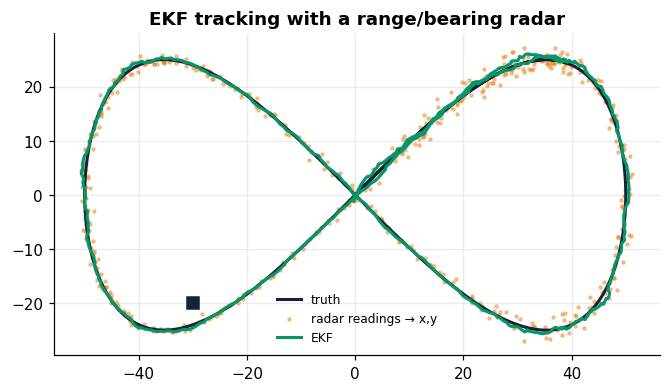

Position RMSE: converted radar readings 1.11 m  ->  EKF 0.56 m
✅ EKF works. Next steps up: the UKF (no Jacobians) and particle filters (non-Gaussian banana shapes).


In [57]:
def ekf_update(kf, z, s, R):
    """Apply one Extended Kalman Filter update for a range-bearing sensor.

    Linearizes the nonlinear measurement function `h_rb` at the current
    state estimate, then applies the standard linear Kalman update with
    that Jacobian as `H`.

    Args:
        kf: A `KalmanFilter` instance, updated in place.
        z: Measurement `[range, bearing]`.
        s: Radar position `[sx, sy]`.
        R: Measurement noise covariance for `[range, bearing]`.

    Returns:
        None: Updates `kf.x` and `kf.P` in place.
    """
    H = H_rb(kf.x, s)
    y = z - h_rb(kf.x, s)
    y[1] = (y[1] + np.pi) % (2 * np.pi) - np.pi                 # bearing residual must wrap to [-π, π]
    S = H @ kf.P @ H.T + R
    K = kf.P @ H.T @ np.linalg.inv(S)
    kf.x = kf.x + K @ y
    kf.P = (np.eye(4) - K @ H) @ kf.P

def _bonus_ready():
    try:
        h_rb(np.array([30., 10., 1., 2.]), RADAR_POS)
        H_rb(np.array([30., 10., 1., 2.]), RADAR_POS)
        return True
    except NotImplementedError:
        return False

if not _bonus_ready():
    print("Phần 8 là bonus sau giờ — bỏ qua phần demo EKF.")
else:
    SIG_R, SIG_B = 0.5, np.radians(1.0)
    R_rb = np.diag([SIG_R ** 2, SIG_B ** 2])
    rng8 = np.random.default_rng(8)
    zs = np.array([h_rb(s_, RADAR_POS) for s_ in S2]) + rng8.normal(0, [SIG_R, SIG_B], (len(t2), 2))

    x0e = np.array([*(RADAR_POS + zs[0, 0] * np.array([np.cos(zs[0, 1]), np.sin(zs[0, 1])])), 0., 0.])
    kf = KalmanFilter(x0e, np.diag([5. ** 2, 5. ** 2, 10. ** 2, 10. ** 2]))
    path = [x0e.copy()]
    for k in range(1, len(t2)):
        kf.predict(make_F(DT2), make_Q(DT2, 0.5))
        ekf_update(kf, zs[k], RADAR_POS, R_rb)
        path.append(kf.x.copy())
    path = np.array(path)

    raw_xy = RADAR_POS + zs[:, :1] * np.stack([np.cos(zs[:, 1]), np.sin(zs[:, 1])], axis=1)
    e_raw, e_ekf = np.linalg.norm(raw_xy - S2[:, :2], axis=1), np.linalg.norm(path[:, :2] - S2[:, :2], axis=1)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(S2[:, 0], S2[:, 1], color=INK, lw=2, label="truth"); ax.scatter(*raw_xy.T, s=4, color=ORANGE, alpha=.4, label="radar readings → x,y")
    ax.plot(path[:, 0], path[:, 1], color=GREEN, lw=2, label="EKF"); ax.plot(*RADAR_POS, "s", color=INK, ms=8)
    ax.set(aspect="equal", title="EKF tracking with a range/bearing radar"); ax.legend(fontsize=8); plt.show()
    print(f"Position RMSE: converted radar readings {rmse(e_raw):.2f} m  ->  EKF {rmse(e_ekf[50:]):.2f} m")
    assert rmse(e_ekf[50:]) < rmse(e_raw)
    print("✅ EKF works. Next steps up: the UKF (no Jacobians) and particle filters (non-Gaussian banana shapes).")


### ▶️ Sau giờ · Cửa sổ hiệu chỉnh 0–20 giây (không chấm)
Burst outlier luôn bắt đầu sau giây 25, nên 20 giây đầu thường không lộ kiểu lỗi đó. Đừng dùng mục này để quyết định chẩn đoán.
🎯 Trong thực tế, bạn hiếm khi được "nhìn trộm" toàn bộ dữ liệu trước khi quyết định tham số — bạn phải hiệu chỉnh trên dữ liệu đã có, rồi hy vọng nó vẫn đúng cho phần dữ liệu sắp tới (giống hệt bài 4.1, nhưng giờ bạn tự chia cửa sổ).

Giả sử bạn chỉ có **20 giây đầu** của nhiệm vụ khi phải quyết định tham số (phần "hiệu chỉnh" / calibration). Chạy lại `diagnose()` chỉ trên 20 giây đó, so sánh với chẩn đoán đầy đủ ở 9.1, rồi xem bộ lọc ở 9.2 (đã chạy trên **toàn bộ** nhiệm vụ) có NIS ổn định ra sao trên phần **sau** giây 20 ("vận hành" / operational) — phần mà bạn *chưa* dùng để quyết định tham số.


In [58]:
def slice_mission(mission, t_min=None, t_max=None):
    """Return a copy of a mission restricted to a time window.

    Args:
        mission: A mission dict as returned by `generate_mission_log`.
        t_min: If given, drop measurements before this time (inclusive).
        t_max: If given, drop measurements at or after this time.

    Returns:
        dict: A new mission dict with the same structure, containing only
        the measurements whose timestamp falls in `[t_min, t_max)`.
    """
    out = dict(mission)
    for name in ["gps", "uwb"]:
        t = mission[f"t_{name}"]; z = mission[f"z_{name}"]
        mask = np.ones_like(t, dtype=bool)
        if t_min is not None:
            mask &= t >= t_min
        if t_max is not None:
            mask &= t < t_max
        out[f"t_{name}"] = t[mask]; out[f"z_{name}"] = z[mask]
    return out

RUN_OPTIONAL_93 = False  # đặt True chỉ khi làm phần sau giờ
calib = slice_mission(mission, t_max=20.0)
print(f"Cửa sổ hiệu chỉnh (0-20s): {len(calib['t_gps'])} điểm GPS, {len(calib['t_uwb'])} điểm UWB")
print("Burst outlier luôn bắt đầu sau giây 25, nên 20 giây đầu không phải lúc nào cũng lộ lỗi. Mục này không chấm.")
if not RUN_OPTIONAL_93:
    calib_diag = None
    operational_nis = np.array([])
    print("Bỏ qua phần sau giờ. Đặt RUN_OPTIONAL_93 = True để chạy.")
else:
    calib_diag = diagnose(calib)
    for name in ["GPS", "UWB"]:
        d = calib_diag[name]
        print(f"[hiệu chỉnh] {name}: mean(NIS)={d['nis'].mean():.2f}  median(NIS)={np.median(d['nis']):.2f}")
    ts_all = np.array([l[0] for l in log])
    operational_nis = nis_all[ts_all >= 20.0]
    print("NIS trên cửa sổ VẬN HÀNH (sau giây 20, %d điểm): mean=%.2f  median=%.2f" % (
        len(operational_nis), operational_nis.mean(), np.median(operational_nis)))


Cửa sổ hiệu chỉnh (0-20s): 100 điểm GPS, 200 điểm UWB
Burst outlier luôn bắt đầu sau giây 25, nên 20 giây đầu không phải lúc nào cũng lộ lỗi. Mục này không chấm.
Bỏ qua phần sau giờ. Đặt RUN_OPTIONAL_93 = True để chạy.


In [59]:
def check_calib_split():
    """Optional after-class check. Quiet while the section is left off.

    Raises:
        AssertionError: If the optional path ran but the windows are empty or non-finite.
    """
    if calib_diag is None:
        print("Cửa sổ hiệu chỉnh đang tắt (phần sau giờ, không chấm).")
        return
    assert len(calib["t_gps"]) > 0 and len(calib["t_uwb"]) > 0
    assert isinstance(calib_diag, dict) and set(calib_diag.keys()) == {"GPS", "UWB"}
    assert len(operational_nis) > 0 and np.all(np.isfinite(operational_nis))
    print(f"✅ Tinh chỉnh không nhìn trộm chạy hợp lệ. NIS vận hành trung bình = {operational_nis.mean():.2f}.")
check_calib_split()


Cửa sổ hiệu chỉnh đang tắt (phần sau giờ, không chấm).


**Ghi chú (không chấm, sau giờ):**

- Chẩn đoán chỉ dựa trên 20 giây đầu có khớp với chẩn đoán đầy đủ ở 9.1 không? ______________
- NIS trên cửa sổ "vận hành" (sau giây 20) so với toàn bộ nhiệm vụ: tốt hơn / tệ hơn / tương đương? Vì sao theo bạn? ______________
- Nếu nhiệm vụ dài gấp 10 lần, bạn có tin tham số hiệu chỉnh từ 20 giây đầu vẫn ổn không? ______________


### ▶️ Sau giờ · Suy luận mất tín hiệu (không chấm)
Không viết code cho bài này. Giả sử **giữa nhiệm vụ**, cảm biến **GPS mất tín hiệu hoàn toàn trong 15 giây** (ví dụ xe chạy dưới cầu vượt), trong khi UWB vẫn hoạt động bình thường. Trả lời bằng chính kiến thức bạn đã xây dựng từ Phần 3–7:

**a)** Trong 15 giây đó, ma trận hiệp phương sai `P` của bộ lọc sẽ thay đổi ra sao? Thành phần nào của `P` tăng nhanh nhất, và tại sao (liên hệ tới `Q`, bài 3 và 5)?

**b)** Sau khi GPS có tín hiệu trở lại, điều gì quyết định việc bộ lọc "tin tưởng lại" phép đo GPS nhanh hay chậm? (liên hệ hệ số Kalman `K`, bài 2 và 3)

**c)** Đề xuất **một** thay đổi trong thiết kế bộ lọc (không cần code, chỉ cần mô tả) để xử lý tốt hơn tình huống mất tín hiệu kéo dài. Gợi ý để nghĩ xa hơn: điều gì xảy ra nếu UWB *cũng* mất tín hiệu cùng lúc?

**Ghi chú (không chấm, sau giờ):**

a) ______________

b) ______________

c) ______________


### 🌟 Thử thách thêm (không bắt buộc, tối đa +5 điểm thưởng)
Chọn **một** trong các hướng sau và làm thêm nếu còn thời gian:
- Áp dụng ý tưởng UKF/EKF (Phần 8) nếu bạn giả định cảm biến UWB thực ra đo *khoảng cách tới 3 trạm neo* (anchor) thay vì toạ độ (x, y) trực tiếp — bài toán định vị đa điểm (multilateration) phi tuyến.
- Thiết kế một chỉ số cảnh báo tự động (không cần biết trước loại lỗi) để hệ thống tự phát hiện "có gì đó bất thường" theo thời gian thực, không cần chờ hết nhiệm vụ.
- Giả sử **cả hai** cảm biến đều có thể lỗi cùng lúc (không chỉ một) — thiết kế lại chiến lược chẩn đoán của bạn cho trường hợp tổng quát hơn này.
- Vẽ thêm biểu đồ histogram phân bố NIS của từng cảm biến, so với phân phối χ² lý thuyết (bậc tự do = 2) để chẩn đoán định lượng hơn là chỉ nhìn mean/median.

**Hướng đã chọn: Histogram NIS của từng cảm biến so với χ²(2), trước và sau sửa bias.**

Với phép đo vị trí hai chiều và mô hình nhất quán, NIS có kỳ vọng 2, trung vị khoảng 1,386 và khoảng 5% giá trị vượt χ²(0,95; 2) ≈ 5,991. Tôi so sánh phân bố thực nghiệm của GPS và UWB trước/sau hiệu chỉnh để xem cách sửa đưa NIS về gần phân bố lý thuyết đến mức nào. Phần sau sửa vẫn dùng q = 0,3 và mức nhiễu SPEC của đề, không điều chỉnh thêm tham số.


χ²(2): mean=2, median=1.386, ngưỡng 95%=5.991
Cảm biến / giai đoạn: mean NIS; median NIS; tỷ lệ > ngưỡng 95%; residual trung bình (m)
GPS / Trước sửa: 11.503; 10.233; 81.33%; [-0.053  1.818] (ngoài vùng vẽ: 2 mẫu)


GPS / Sau sửa bias UWB: 2.858; 1.755; 11.11%; [-0.024  0.505] (ngoài vùng vẽ: 1 mẫu)


UWB / Trước sửa: 14.045; 13.009; 87.33%; [ 0.079 -3.591] (ngoài vùng vẽ: 10 mẫu)
UWB / Sau sửa bias UWB: 3.039; 2.034; 13.22%; [ 0.022 -1.015] (ngoài vùng vẽ: 1 mẫu)


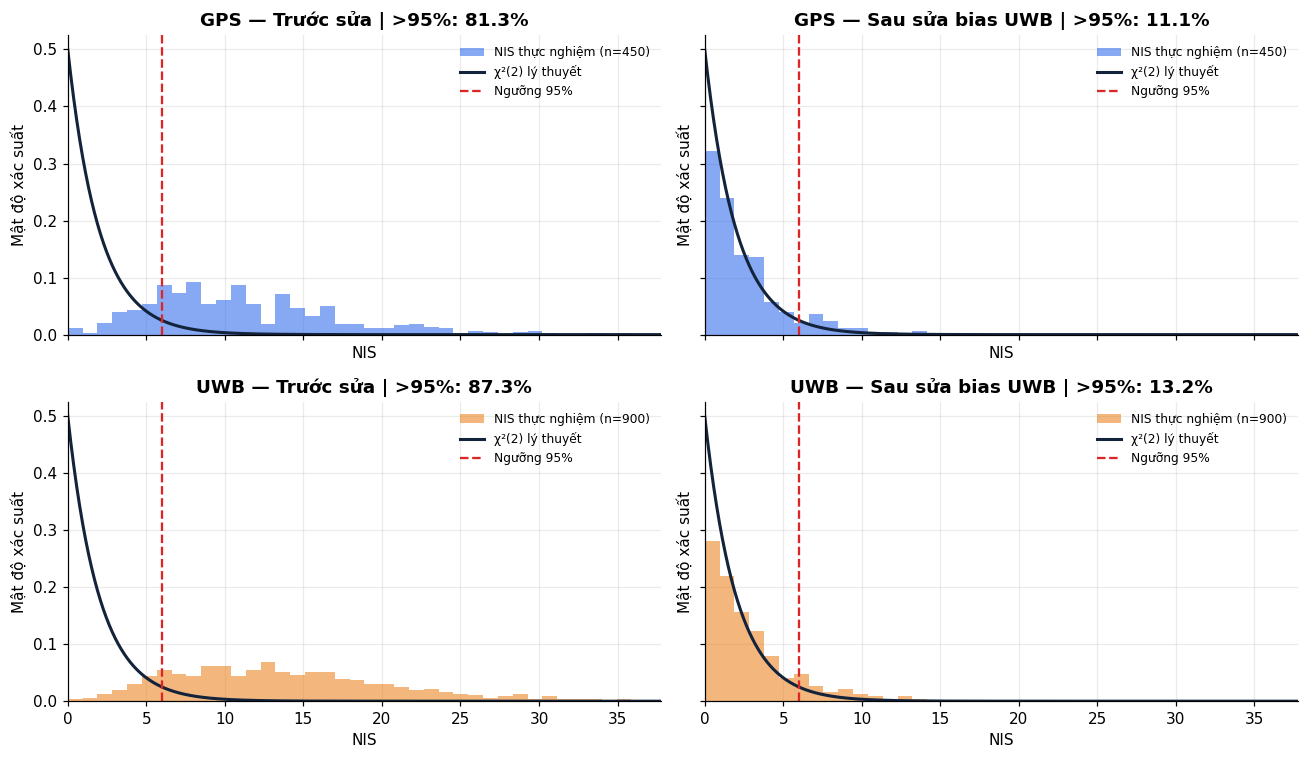

✅ Bonus: đã so sánh histogram NIS GPS/UWB trước và sau sửa với χ²(2).


In [60]:
# Thử thách bonus: phân bố NIS trước/sau hiệu chỉnh bias UWB.
# Tạo bản sao dữ liệu đo; giữ nguyên mission và kết quả Phần 9.
mission_corrected = dict(mission)
mission_corrected["z_uwb"] = mission["z_uwb"] - kw["uwb_bias_corr"]
diag_corrected = diagnose(mission_corrected)

threshold_95 = chi2.ppf(0.95, df=2)
theory_median = chi2.ppf(0.5, df=2)
all_sensor_nis = np.concatenate([
    d[name]["nis"] for d in [diag, diag_corrected] for name in ["GPS", "UWB"]
])
# Cùng một trục và các bin; phần đuôi ngoài vùng vẽ vẫn được tính trong bảng.
x_limit = max(12.0, float(np.percentile(all_sensor_nis, 99.5)))
bins = np.linspace(0.0, x_limit, 41)
xs = np.linspace(0.0, x_limit, 600)
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
print(f"χ²(2): mean=2, median={theory_median:.3f}, ngưỡng 95%={threshold_95:.3f}")
print("Cảm biến / giai đoạn: mean NIS; median NIS; tỷ lệ > ngưỡng 95%; residual trung bình (m)")
for row, name in enumerate(["GPS", "UWB"]):
    for col, (stage, diagnostic) in enumerate([
        ("Trước sửa", diag), ("Sau sửa bias UWB", diag_corrected)
    ]):
        values = diagnostic[name]["nis"]
        assert len(values) == len(mission["t_" + name.lower()])
        assert np.all(np.isfinite(values)) and np.all(values >= 0)
        # Chuẩn hóa theo TOÀN BỘ mẫu, không chuẩn hóa lại phần bị giới hạn trục x.
        weights = np.full(len(values), 1.0 / (len(values) * (bins[1] - bins[0])))
        ax = axes[row, col]
        ax.hist(values, bins=bins, weights=weights, color=BLUE if name == "GPS" else ORANGE,
                alpha=0.55, label=f"NIS thực nghiệm (n={len(values)})")
        ax.plot(xs, chi2.pdf(xs, df=2), color=INK, lw=2, label="χ²(2) lý thuyết")
        ax.axvline(threshold_95, color=RED, ls="--", label="Ngưỡng 95%")
        tail = 100.0 * np.mean(values > threshold_95)
        outside = np.count_nonzero(values > x_limit)
        ax.set(title=f"{name} — {stage} | >95%: {tail:.1f}%",
               xlabel="NIS", ylabel="Mật độ xác suất", xlim=(0, x_limit))
        ax.legend(fontsize=8)
        print(f"{name} / {stage}: {values.mean():.3f}; {np.median(values):.3f}; "
              f"{tail:.2f}%; {np.round(diagnostic[name]['resid_mean'], 3)} "
              f"(ngoài vùng vẽ: {outside} mẫu)")
plt.tight_layout()
plt.show()
print("✅ Bonus: đã so sánh histogram NIS GPS/UWB trước và sau sửa với χ²(2).")


**Nhận xét từ histogram và output bonus**

| Cảm biến | Giai đoạn | Mean NIS | Median NIS | Tỷ lệ NIS > 5,991 |
|:--|:--|--:|--:|--:|
| GPS | Trước sửa | 11,503 | 10,233 | 81,33% |
| GPS | Sau sửa bias UWB | 2,858 | 1,755 | 11,11% |
| UWB | Trước sửa | 14,045 | 13,009 | 87,33% |
| UWB | Sau sửa bias UWB | 3,039 | 2,034 | 13,22% |
| χ²(2) lý thuyết | Mô hình nhất quán | 2,000 | 1,386 | 5,00% |

Trước sửa, cả hai phân bố lệch sang vùng NIS lớn, không chỉ có một vài giá trị cực đoan. Sau hiệu chỉnh UWB, cả hai histogram tiến gần đường χ²(2), phù hợp với việc một cảm biến bị bias làm sai lệch cả bộ lọc chung. Việc GPS cũng cải thiện dù không sửa phép đo GPS củng cố lựa chọn hiệu chỉnh UWB.

Tuy nhiên, sau sửa, tỷ lệ vượt ngưỡng vẫn là 11,11% và 13,22%, cao hơn kỳ vọng 5%. Residual trung bình còn [-0,024; 0,505] m ở GPS và [0,022; -1,015] m ở UWB. Các số này cho thấy bộ lọc chưa hoàn toàn nhất quán với mô hình Gaussian không bias; chúng phù hợp với hạn chế rằng lấy residual từ bộ lọc đã bị kéo lệch chỉ ước lượng được một phần bias. Đây là dấu hiệu cần kiểm chứng thêm, không phải bằng chứng độc lập xác nhận bias thật hay sai số vị trí vì không có ground truth.

Histogram dùng cùng các bin và cùng phạm vi trục để dễ so sánh. Các mẫu vượt phạm vi hiển thị vẫn được tính trong mean, median và tỷ lệ vượt ngưỡng; mật độ histogram được chuẩn hóa theo toàn bộ số mẫu. Ngưỡng 95% ở đây dùng để đánh giá phân bố, không được dùng để loại bỏ phép đo trong cách sửa bias đã chọn.


---
## 📋 Thang điểm chấm bài (100 điểm, thưởng tối đa +5 tách riêng)

Làm trong **120 phút**. 80 điểm là tự động. 20 điểm là một báo cáo. Phần 1–4 không chấm.

### A. Tự code trên lớp — 50 điểm
| Bài | Điều kiện | Điểm |
|:--|:--|--:|
| 5.1 | `check_matrices()` in `✅ Exercise 5.1 passed` | 10 |
| 5.2 | `check_kf_class()` in `✅ Exercise 5.2 passed` | 15 |
| 6.1 | `check_run_fusion()` in `✅ Exercise 6.1 passed` | 15 |
| 7.1 | `check_gate()` in `✅ Exercise 7.1 passed` | 10 |

Sai hoặc chưa làm thì 0 điểm bài đó. Không có điểm một phần ở mục này.

### B. Phần 9 · Nhiệm vụ — 30 điểm tự động + 20 điểm báo cáo
| Mục | Điều kiện | Điểm |
|:--|:--|--:|
| 9.1 Chẩn đoán | Đúng cảm biến và đúng loại lỗi | 15 |
| 9.1 một phần | Đúng cảm biến, sai loại lỗi | 8 |
| 9.2 NIS | Pooled mean NIS < 8 (ô kiểm tra in dòng hợp lệ) | 8 |
| 9.2 Cách sửa | `FIX_SENSOR` đúng cảm biến thật và `FIX_METHOD` đúng kiểu lỗi (`bias`, `inflate_R`, hoặc `gate`) | 7 |
| Báo cáo | Một ô viết tay: bằng chứng số của bạn, cách sửa, 1σ cuối, một hạn chế | 20 |

`STUDENT_ID` để nguyên câu mẫu thì toàn bộ Phần 9 = 0.

### Thưởng — tối đa +5, không cộng vào 80 điểm tự động
Làm Phần 8 (bài 8.1) hoặc một mục thử thách sau giờ. Giảng viên cộng tối đa 5 điểm cho cả hai cộng lại.

### Liêm chính
Mỗi `STUDENT_ID` một log. Chép nhãn của bạn khác sẽ không khớp dữ liệu của bạn. Báo cáo phải dẫn đúng số mà chính notebook của bạn in ra.
